In [ ]:
# Install dependencies (only needed once per environment)
%pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn \
                 xgboost shap joblib tensorflow


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, time, joblib, json

warnings.filterwarnings('ignore')
from IPython.display import display

# Scikit-learn
from sklearn.model_selection  import train_test_split, StratifiedKFold
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.metrics          import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score,
    precision_recall_curve, average_precision_score,
)
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# Gradient boosting
from xgboost import XGBClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

# Oversampling & explainability
from imblearn.over_sampling import SMOTE
import shap

print(f'Pandas {pd.__version__} | XGBoost {xgb.__version__} '
      f'| TF {tf.__version__} | SHAP {shap.__version__}')
print('✅ All libraries loaded.')


Pandas 2.2.3 | XGBoost 3.1.2 | TF 2.20.0 | SHAP 0.51.0
✅ All libraries loaded.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Professional colour palette ──────────────────────────────────────────
# Cohesive blue-family theme: every chart uses tones from the same hue
# family, with a single warm accent (amber dashes) for portfolio avg lines.

C_NAVY    = '#1B3A5C'   # headings / title text
C_BLUE_1  = '#1A6FA8'   # primary bars (darkest blue — high values / high risk)
C_BLUE_2  = '#2E9BD6'   # secondary bars (mid blue)
C_BLUE_3  = '#74C0E8'   # tertiary / lighter shade
C_BLUE_4  = '#B8DFF5'   # very light blue (low values / low risk)
C_STEEL   = '#2E86C1'   # alias kept for backward compatibility
C_SLATE   = '#374151'   # axis labels / body text
C_MID     = '#8C9BAD'   # captions / secondary annotations
C_LIGHT   = '#F4F8FC'   # axes background
C_AMBER   = '#E07B00'   # portfolio avg dashed line (single warm accent)
C_DARK    = '#1C2833'   # Neural Network / darkest model colour

# Semantic aliases (used in plot helpers below)
C_GREEN   = C_BLUE_2    # "approved / safe"  → now a mid-blue
C_RED     = C_BLUE_1    # "default / danger" → now a dark blue (darker = more risk)

# ── Named colours for each model ────────────────────────────────────────
C_CAT_1   = '#2E86C1'
C_CAT_2   = '#1A6FA8'
C_TEAL    = '#138086'   # Decision Tree
C_CRIMSON = '#1A6FA8'   # XGBoost (dark blue)
C_PURPLE  = '#5B5EA6'   # Random Forest (muted indigo — still distinct)

MODEL_COLORS = {
    'Logistic Regression': '#2E86C1',
    'Decision Tree'      : '#138086',
    'Random Forest'      : '#5B5EA6',
    'XGBoost'            : '#1A6FA8',
    'Neural Network'     : C_DARK,
}

# ── Seaborn default palette ──────────────────────────────────────────────
PALETTE = [C_BLUE_1, C_BLUE_2, C_AMBER, '#5B5EA6', '#138086']
sns.set_palette(PALETTE)

# ── Matplotlib global style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 150,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : C_LIGHT,
    'axes.grid'         : True,
    'grid.alpha'        : 0.45,
    'grid.color'        : '#D5E4EF',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : True,
    'axes.spines.bottom': True,
    'axes.edgecolor'    : '#B0C4D8',
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.titlecolor'   : C_NAVY,
    'axes.titlepad'     : 15,
    'axes.labelsize'    : 11,
    'axes.labelweight'  : '500',
    'axes.labelcolor'   : C_SLATE,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'xtick.color'       : C_SLATE,
    'ytick.color'       : C_SLATE,
    'legend.fontsize'   : 10,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#D5E4EF',
    'font.family'       : 'sans-serif',
})

# ── Helper utilities ─────────────────────────────────────────────────────
def pct(s):
    return f'{round(s * 100, 2)}%'

def polish(ax, xlabel=None, ylabel=None):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.45, color='#D5E4EF')
    ax.grid(axis='x', visible=False)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11, color=C_SLATE, weight='500')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11, color=C_SLATE, weight='500')

def pd_bar_colors(values, n_shades=4):
    """Return a blue shade per bar: higher PD → darker blue."""
    blues = ['#B8DFF5', '#74C0E8', '#2E9BD6', '#1A6FA8']
    vals  = np.array(values, dtype=float)
    norm  = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    idxs  = np.clip((norm * (len(blues) - 1)).round().astype(int), 0, len(blues)-1)
    return [blues[i] for i in idxs]

def gradient_colors(values, lo=C_BLUE_4, hi=C_BLUE_1):
    """Map a numeric array to a blue-shade gradient (light → dark)."""
    vals  = np.array(values, dtype=float)
    norm  = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    lo_rgb = [int(lo[i:i+2], 16) / 255 for i in (1, 3, 5)]
    hi_rgb = [int(hi[i:i+2], 16) / 255 for i in (1, 3, 5)]
    return [tuple(lo_rgb[j] + (hi_rgb[j] - lo_rgb[j]) * n for j in range(3))
            for n in norm]

def occupation_group(job):
    if pd.isna(job):
        return 'N/A'
    low_skill  = {'Laborers', 'Low-skill Laborers', 'Drivers', 'Cleaning staff',
                  'Cooking staff', 'Waiters/barmen staff', 'Security staff'}
    mid_skill  = {'Core staff', 'Sales staff', 'Private service staff',
                  'Secretaries', 'HR staff', 'Realty agents'}
    high_skill = {'Accountants', 'Managers', 'Medicine staff',
                  'High skill tech staff', 'IT staff'}
    if job in low_skill:  return 'Low-Skill & Manual'
    if job in mid_skill:  return 'Mid-Skill & Office'
    if job in high_skill: return 'High-Skill & Professional'
    return 'N/A'

print('✅ Professional thesis style configuration ready.')


✅ Professional thesis style configuration ready.


In [4]:
DATA_PATH = './data/'   # ← update to your local folder

application_train = pd.read_csv(DATA_PATH + 'application_train.csv')
application_test  = pd.read_csv(DATA_PATH + 'application_test.csv')
bureau_credit     = pd.read_csv(DATA_PATH + 'bureau.csv')

print(f'application_train : {application_train.shape}')
print(f'application_test  : {application_test.shape}')
print(f'bureau_credit     : {bureau_credit.shape}')


application_train : (307511, 122)
application_test  : (48744, 121)
bureau_credit     : (1716428, 17)


In [5]:
def missing_values_table(df):
    """Return a sorted DataFrame of missing-value counts and percentages."""
    mis     = df.isnull().sum()
    pct_mis = 100 * mis / len(df)
    t = (pd.concat([mis, pct_mis], axis=1)
           .rename(columns={0: 'Missing Values', 1: '% of Total Values'})
           .query('`% of Total Values` > 0')
           .sort_values('% of Total Values', ascending=False)
           .round(1))
    print(f'{df.shape[1]} columns total — {len(t)} have missing values.')
    return t


missing_values = missing_values_table(application_train).reset_index()
missing_values.rename(columns={'index': 'Column Name'}, inplace=True)
print('Top 10 columns with the most missing values:')
display(missing_values.head(10))


122 columns total — 67 have missing values.
Top 10 columns with the most missing values:


,Column Name,Missing Values,% of Total Values
0,COMMONAREA_MEDI,214865,69.9
1,COMMONAREA_MODE,214865,69.9
2,COMMONAREA_AVG,214865,69.9
3,NONLIVINGAPARTMENTS_MODE,213514,69.4
4,NONLIVINGAPARTMENTS_MEDI,213514,69.4
5,NONLIVINGAPARTMENTS_AVG,213514,69.4
6,FONDKAPREMONT_MODE,210295,68.4
7,LIVINGAPARTMENTS_AVG,210199,68.4
8,LIVINGAPARTMENTS_MEDI,210199,68.4
9,LIVINGAPARTMENTS_MODE,210199,68.4


In [6]:
MISSING_THRESHOLD = 70  # drop columns with > 70 % missing

cols_to_drop = (
    missing_values
    .query('`% of Total Values` > @MISSING_THRESHOLD')['Column Name']
    .tolist()
)

df_train_raw = application_train.drop(columns=cols_to_drop)
df_test_raw  = application_test.drop(
    columns=[c for c in cols_to_drop if c in application_test.columns]
)

print(f'Dropped {len(cols_to_drop)} high-missing columns.')
print(f'df_train_raw : {df_train_raw.shape}  |  df_test_raw : {df_test_raw.shape}')


Dropped 0 high-missing columns.
df_train_raw : (307511, 122)  |  df_test_raw : (48744, 121)


In [7]:
def fix_anomalies(df):
    """Correct known data-entry anomalies. Returns a copy."""
    df = df.copy()
    df.loc[df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan
    if 'CODE_GENDER' in df.columns:
        df.loc[df['CODE_GENDER'] == 'XNA', 'CODE_GENDER'] = np.nan
    floor_cols = [c for c in ['FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE']
                  if c in df.columns]
    if len(floor_cols) > 1:
        df['FLOORSMAX'] = df[floor_cols].mean(axis=1)
        df.drop(columns=floor_cols, inplace=True)
    return df


df_train_clean = fix_anomalies(df_train_raw)
df_test_clean  = fix_anomalies(df_test_raw)

# Save immutable snapshots — never overwritten by EDA or feature engineering
TRAIN_CLEAN_SNAPSHOT = df_train_clean.copy()
TEST_CLEAN_SNAPSHOT  = df_test_clean.copy()

n_anomaly = (application_train['DAYS_EMPLOYED'] == 365243).sum()
print(f'DAYS_EMPLOYED anomaly corrected in {n_anomaly:,} rows.')
print(f'df_train_clean : {df_train_clean.shape}')
print(f'df_test_clean  : {df_test_clean.shape}')
print('✅ Clean snapshots frozen.')


DAYS_EMPLOYED anomaly corrected in 55,374 rows.
df_train_clean : (307511, 120)
df_test_clean  : (48744, 119)
✅ Clean snapshots frozen.


In [8]:
# ── EDA working copy ────────────────────────────────────────────────────
eda_df = df_train_clean.copy()
eda_df['AGE_BIRTH']        = (-eda_df['DAYS_BIRTH'] / 365).astype(int)
eda_df['AGE_GROUP']        = pd.cut(
    eda_df['AGE_BIRTH'],
    bins=[0, 25, 30, 40, 50, 60, 100],
    labels=['<25', '25-30', '30-40', '40-50', '50-60', '60+']
)
eda_df['WORK_EXP_YEARS']   = (-eda_df['DAYS_EMPLOYED'] / 365).clip(lower=0)
eda_df['OCCUPATION_GROUP'] = eda_df['OCCUPATION_TYPE'].map(occupation_group)

print(f'EDA copy shape : {eda_df.shape}')
print(f'TRAIN_CLEAN_SNAPSHOT unchanged : {TRAIN_CLEAN_SNAPSHOT.shape} ✅')


EDA copy shape : (307511, 124)
TRAIN_CLEAN_SNAPSHOT unchanged : (307511, 120) ✅


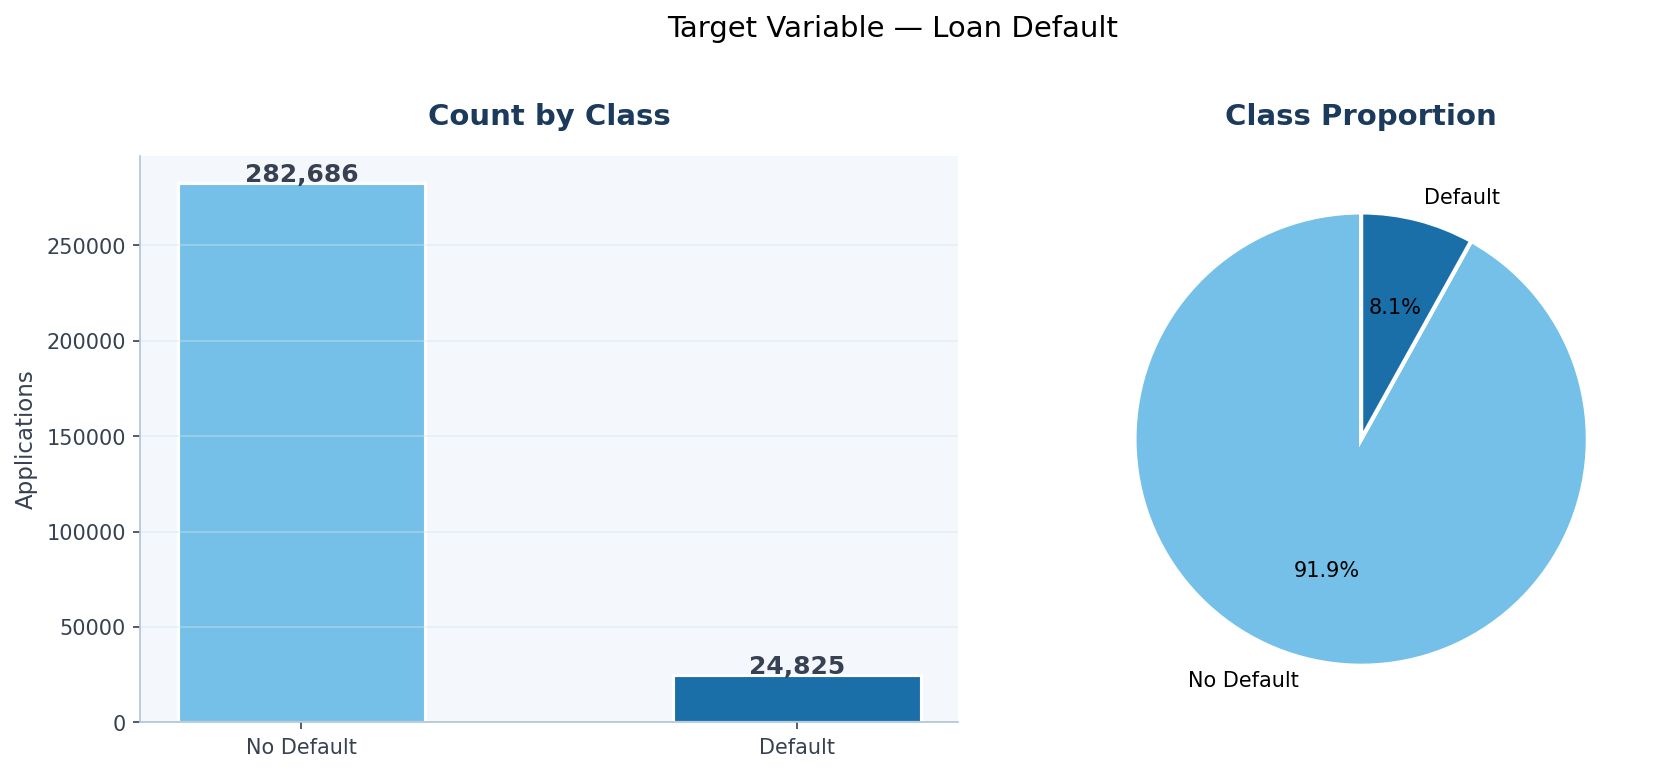

No Default : 282,686  (91.9%)
Default    : 24,825  (8.1%)
Imbalance ratio ≈ 11.4 : 1


In [9]:
tc = eda_df['TARGET'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable — Loan Default', fontsize=14, y=1.02)

# ── Bar chart ────────────────────────────────────────────────────────────
bars = axes[0].bar(
    ['No Default', 'Default'], tc.values,
    color=[C_BLUE_3, C_BLUE_1], edgecolor='white', linewidth=1.5, width=0.5
)
for bar, cnt in zip(bars, tc.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 800,
        f'{cnt:,}', ha='center', fontweight='bold', fontsize=12, color=C_SLATE
    )
polish(axes[0], ylabel='Applications')
axes[0].set_title('Count by Class')

# ── Pie chart ────────────────────────────────────────────────────────────
axes[1].pie(
    tc.values, labels=['No Default', 'Default'],
    autopct='%1.1f%%', colors=[C_BLUE_3, C_BLUE_1],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('eda_01_target.png', bbox_inches='tight', dpi=150)
plt.show()

pct_default = tc[1] / tc.sum() * 100
print(f'No Default : {tc[0]:,}  ({100 - pct_default:.1f}%)')
print(f'Default    : {tc[1]:,}  ({pct_default:.1f}%)')
print(f'Imbalance ratio ≈ {tc[0] / tc[1]:.1f} : 1')


In [10]:
def df_grouped(dataframe, selected_column):
    """Group by a categorical column and return a summary statistics table."""
    g = dataframe.groupby(selected_column, as_index=False).agg(
        Customer_Count    = ('SK_ID_CURR', 'count'),
        Total_Loan_Amount = ('AMT_CREDIT',  'sum'),
        Ticket_size       = ('AMT_CREDIT',  'mean'),
        Default_Count     = ('TARGET', lambda x: (x == 1).sum()),
        Non_Default_Count = ('TARGET', lambda x: (x == 0).sum()),
    )
    g['PD_Rate']             = g['Default_Count'] / (g['Default_Count'] + g['Non_Default_Count'])
    g['Customer_Percentage'] = g['Customer_Count']    / g['Customer_Count'].sum()
    g['Loan_Percentage']     = g['Total_Loan_Amount'] / g['Total_Loan_Amount'].sum()
    g = g.sort_values('PD_Rate')
    g['Total_Loan_Amount'] = (g['Total_Loan_Amount'] / 1e6).round(2)
    g['Ticket_size']       = (g['Ticket_size'] / 1e3).round(1)
    for col in ['PD_Rate', 'Customer_Percentage', 'Loan_Percentage']:
        g[col] = g[col].map(pct)
    return g[[selected_column, 'Customer_Count', 'Customer_Percentage',
               'Total_Loan_Amount', 'Loan_Percentage', 'Ticket_size', 'PD_Rate']]


def plot_categorical(dataframe, selected_column, xlabel_rotation=0):
    """Side-by-side bar charts: customer proportion + PD rate per category."""
    agg  = dataframe[selected_column].value_counts(normalize=True).sort_index()
    pd_r = dataframe.groupby(selected_column)['TARGET'].mean().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Analysis of {selected_column}', fontsize=14)

    # ── Left: Customer Proportion — single steel-blue palette ───────────
    sns.barplot(x=agg.index, y=agg.values * 100, ax=axes[0],
                color=C_STEEL, alpha=0.85)
    axes[0].set_title('Customer Proportion (%)', color=C_NAVY, fontweight='bold')
    axes[0].set_ylabel('%')
    axes[0].tick_params(axis='x', labelrotation=xlabel_rotation)
    for i, v in enumerate(agg.values):
        axes[0].text(i, v * 100 + 0.3, f'{v:.1%}', ha='center', fontsize=8, color=C_SLATE)
    polish(axes[0])

    # ── Right: PD Rate — blue gradient (light = low risk, dark = high risk)
    bar_colors = pd_bar_colors(pd_r.values)
    bars = axes[1].bar(pd_r.index, pd_r.values * 100,
                       color=bar_colors, edgecolor='white', linewidth=1.2)
    axes[1].axhline(dataframe['TARGET'].mean() * 100, color=C_AMBER,
                    linestyle='--', linewidth=1.8, label='Portfolio avg')
    axes[1].set_title('PD Rate (%)', color=C_NAVY, fontweight='bold')
    axes[1].set_ylabel('Default Rate (%)')
    axes[1].tick_params(axis='x', labelrotation=xlabel_rotation)
    axes[1].legend(fontsize=8)
    for bar, val in zip(bars, pd_r.values):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                     f'{val:.1%}', ha='center', fontsize=8, fontweight='bold', color=C_NAVY)
    polish(axes[1])
    plt.tight_layout()
    plt.show()


def plot_numerical(dataframe, col, bins=40):
    """Overlapping density histograms split by default status."""
    d0  = dataframe[dataframe['TARGET'] == 0][col].dropna()
    d1  = dataframe[dataframe['TARGET'] == 1][col].dropna()
    p1, p99 = dataframe[col].quantile([0.01, 0.99]).values

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(d0.clip(p1, p99), bins=bins, alpha=0.55, color=C_BLUE_3,
            label='No Default', density=True)
    ax.hist(d1.clip(p1, p99), bins=bins, alpha=0.75, color=C_BLUE_1,
            label='Default', density=True)
    ax.set_title(f'{col} — Distribution by Default Status')
    ax.legend()
    polish(ax, xlabel=col, ylabel='Density')
    plt.tight_layout()
    plt.show()


print('✅ EDA helper functions ready.')


✅ EDA helper functions ready.


,NAME_CONTRACT_TYPE,Customer_Count,Customer_Percentage,Total_Loan_Amount,Loan_Percentage,Ticket_size,PD_Rate
1,Revolving loans,29279,9.52%,9486.92,5.15%,324.0,5.48%
0,Cash loans,278232,90.48%,174720.16,94.85%,628.0,8.35%


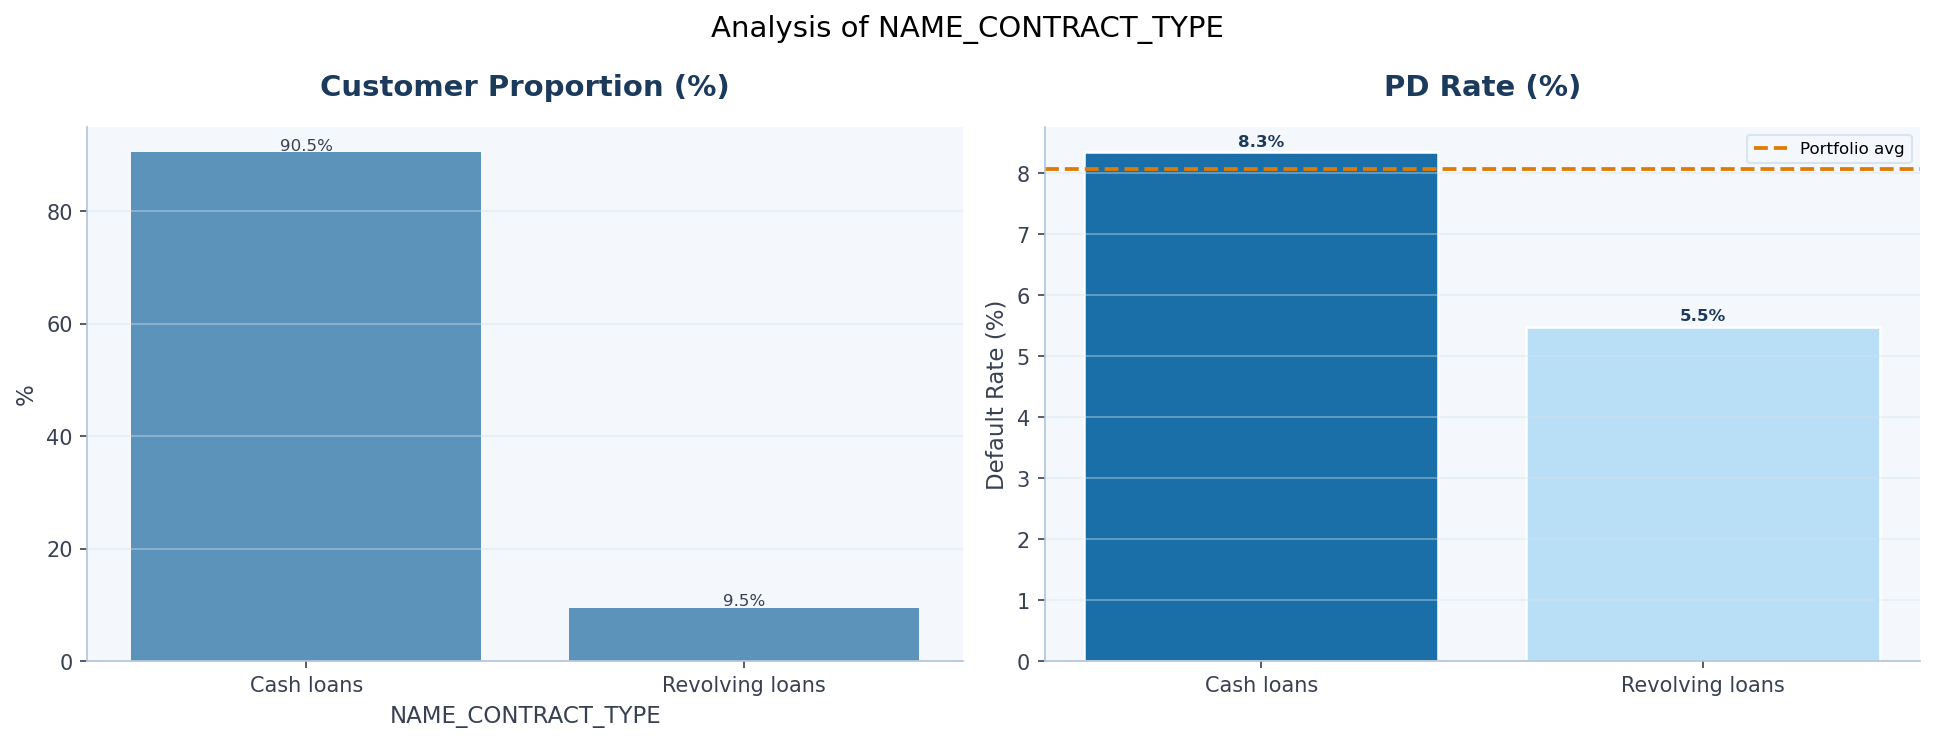

In [11]:
display(df_grouped(eda_df, 'NAME_CONTRACT_TYPE'))
plot_categorical(eda_df, 'NAME_CONTRACT_TYPE')


,AGE_GROUP,Customer_Count,Customer_Percentage,Total_Loan_Amount,Loan_Percentage,Ticket_size,PD_Rate
5,60+,29368,9.55%,14901.10,8.09%,507.4,4.92%
4,50-60,67819,22.05%,43597.19,23.67%,642.8,5.93%
3,40-50,74401,24.19%,49104.26,26.66%,660.0,7.55%
2,30-40,83117,27.03%,50614.63,27.48%,609.0,9.29%
1,25-30,36488,11.87%,19012.24,10.32%,521.1,11.24%
0,<25,16318,5.31%,6977.66,3.79%,427.6,11.74%


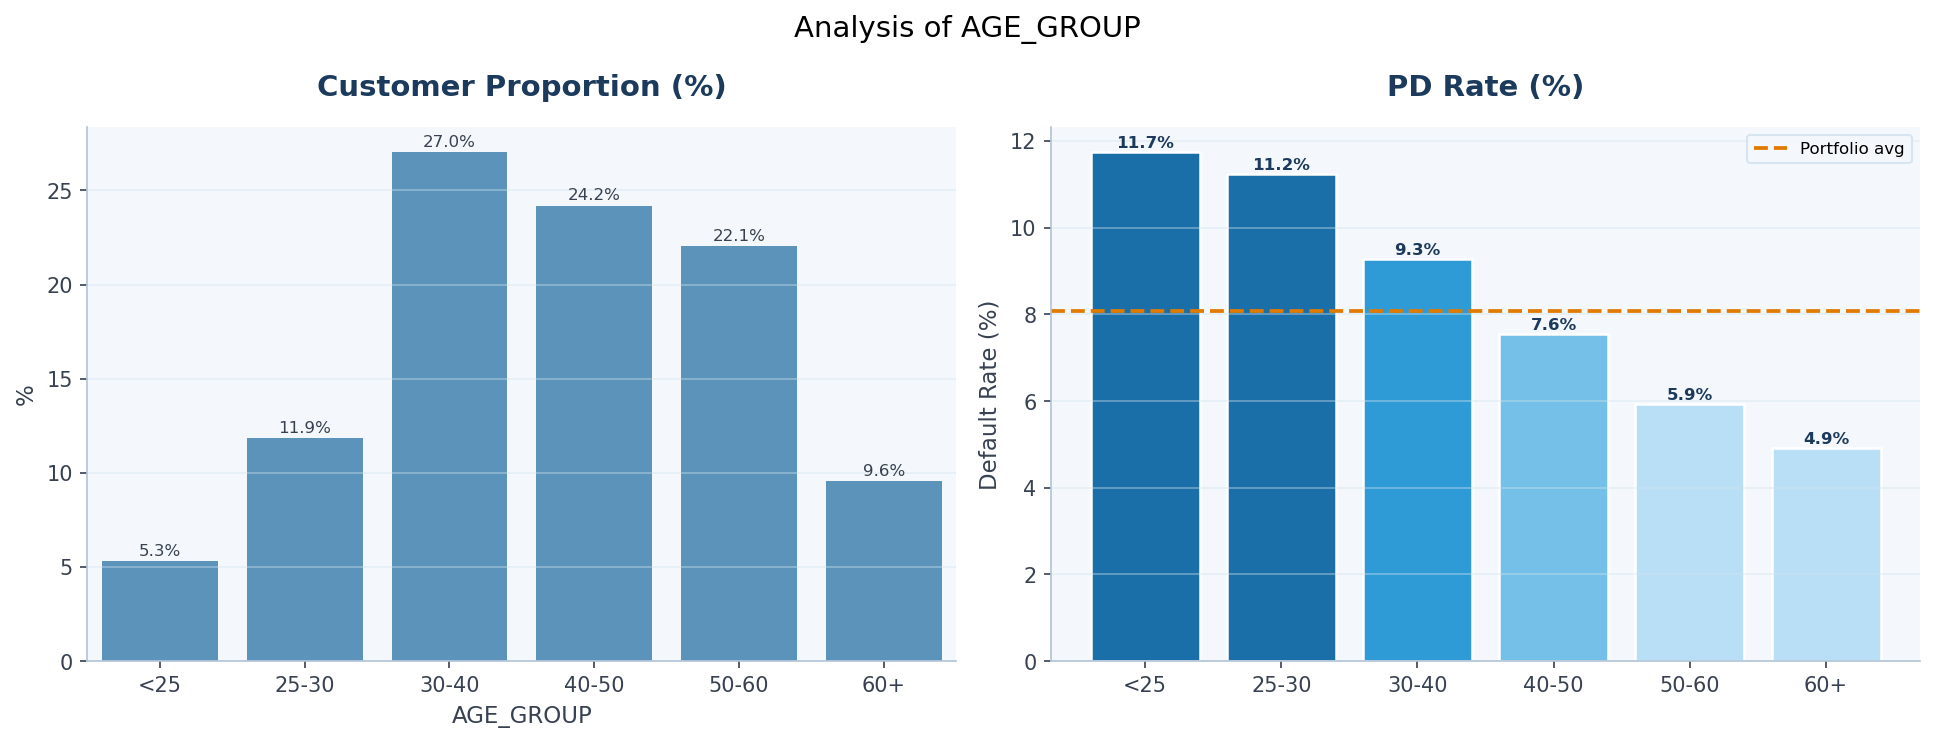

In [12]:
display(df_grouped(eda_df, 'AGE_GROUP'))
plot_categorical(eda_df, 'AGE_GROUP')


,NAME_EDUCATION_TYPE,Customer_Count,Customer_Percentage,Total_Loan_Amount,Loan_Percentage,Ticket_size,PD_Rate
0,Academic degree,164,0.05%,118.66,0.06%,723.5,1.83%
1,Higher education,74863,24.34%,51651.76,28.04%,690.0,5.36%
2,Incomplete higher,10277,3.34%,5824.29,3.16%,566.7,8.48%
4,Secondary / secondary special,218391,71.02%,124743.50,67.72%,571.2,8.94%
3,Lower secondary,3816,1.24%,1868.88,1.01%,489.7,10.93%


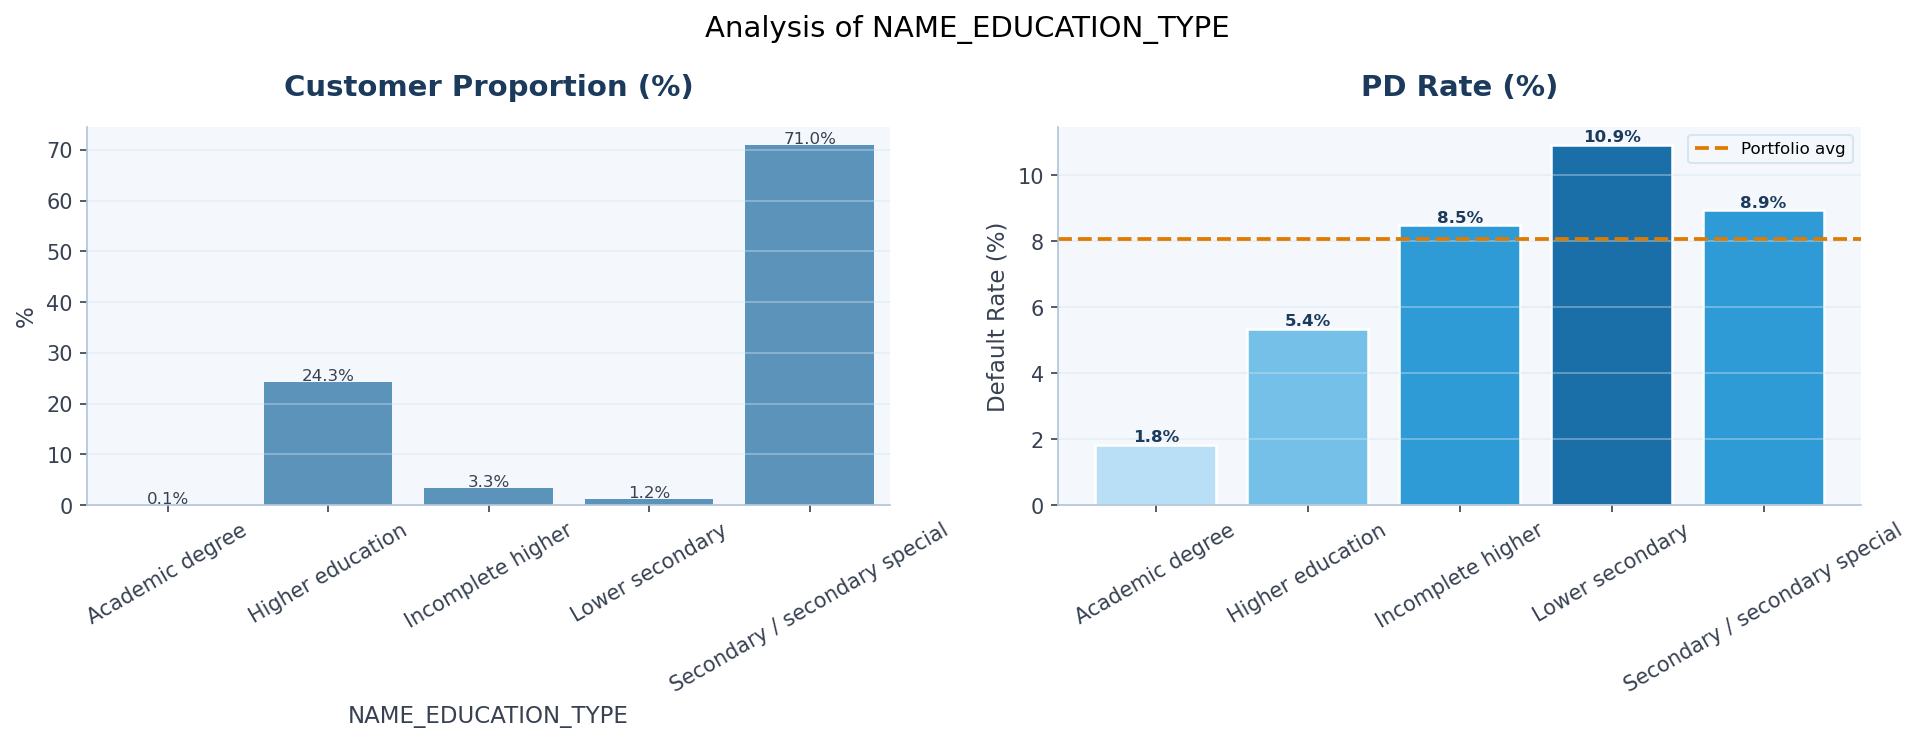

In [13]:
display(df_grouped(eda_df, 'NAME_EDUCATION_TYPE'))
plot_categorical(eda_df, 'NAME_EDUCATION_TYPE', xlabel_rotation=30)


,OCCUPATION_GROUP,Customer_Count,Customer_Percentage,Total_Loan_Amount,Loan_Percentage,Ticket_size,PD_Rate
0,High-Skill & Professional,51627,16.79%,36371.93,19.75%,704.5,6.02%
3,N/A,96391,31.35%,55360.22,30.05%,574.3,6.51%
2,Mid-Skill & Office,64943,21.12%,38643.95,20.98%,595.0,7.99%
1,Low-Skill & Manual,94550,30.75%,53830.99,29.22%,569.3,10.84%


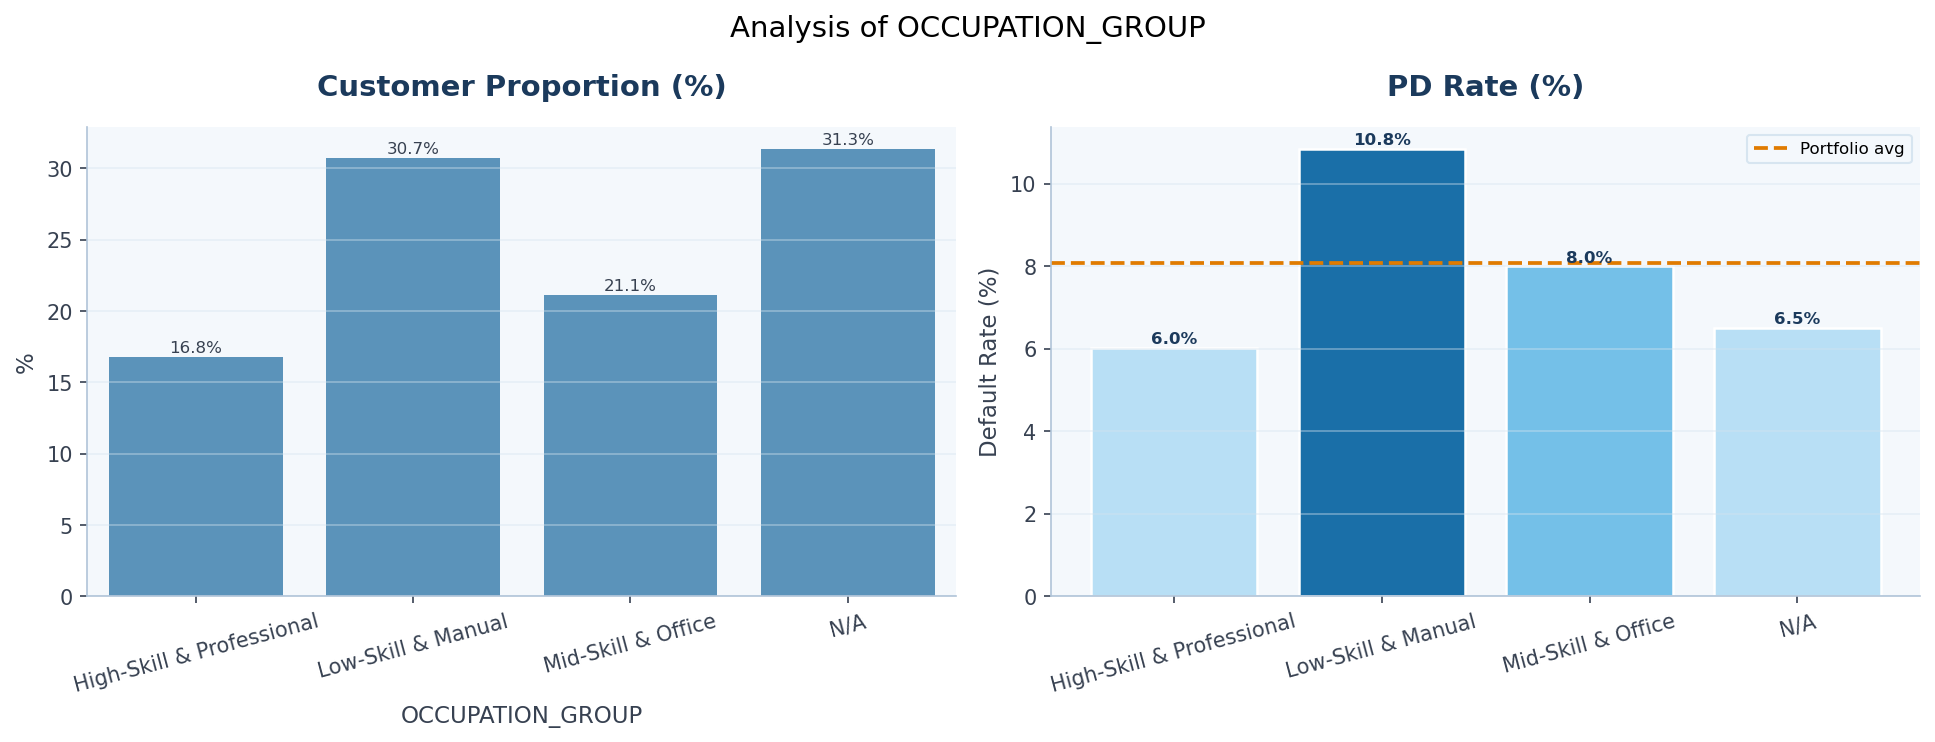

In [14]:
display(df_grouped(eda_df, 'OCCUPATION_GROUP'))
plot_categorical(eda_df, 'OCCUPATION_GROUP', xlabel_rotation=15)


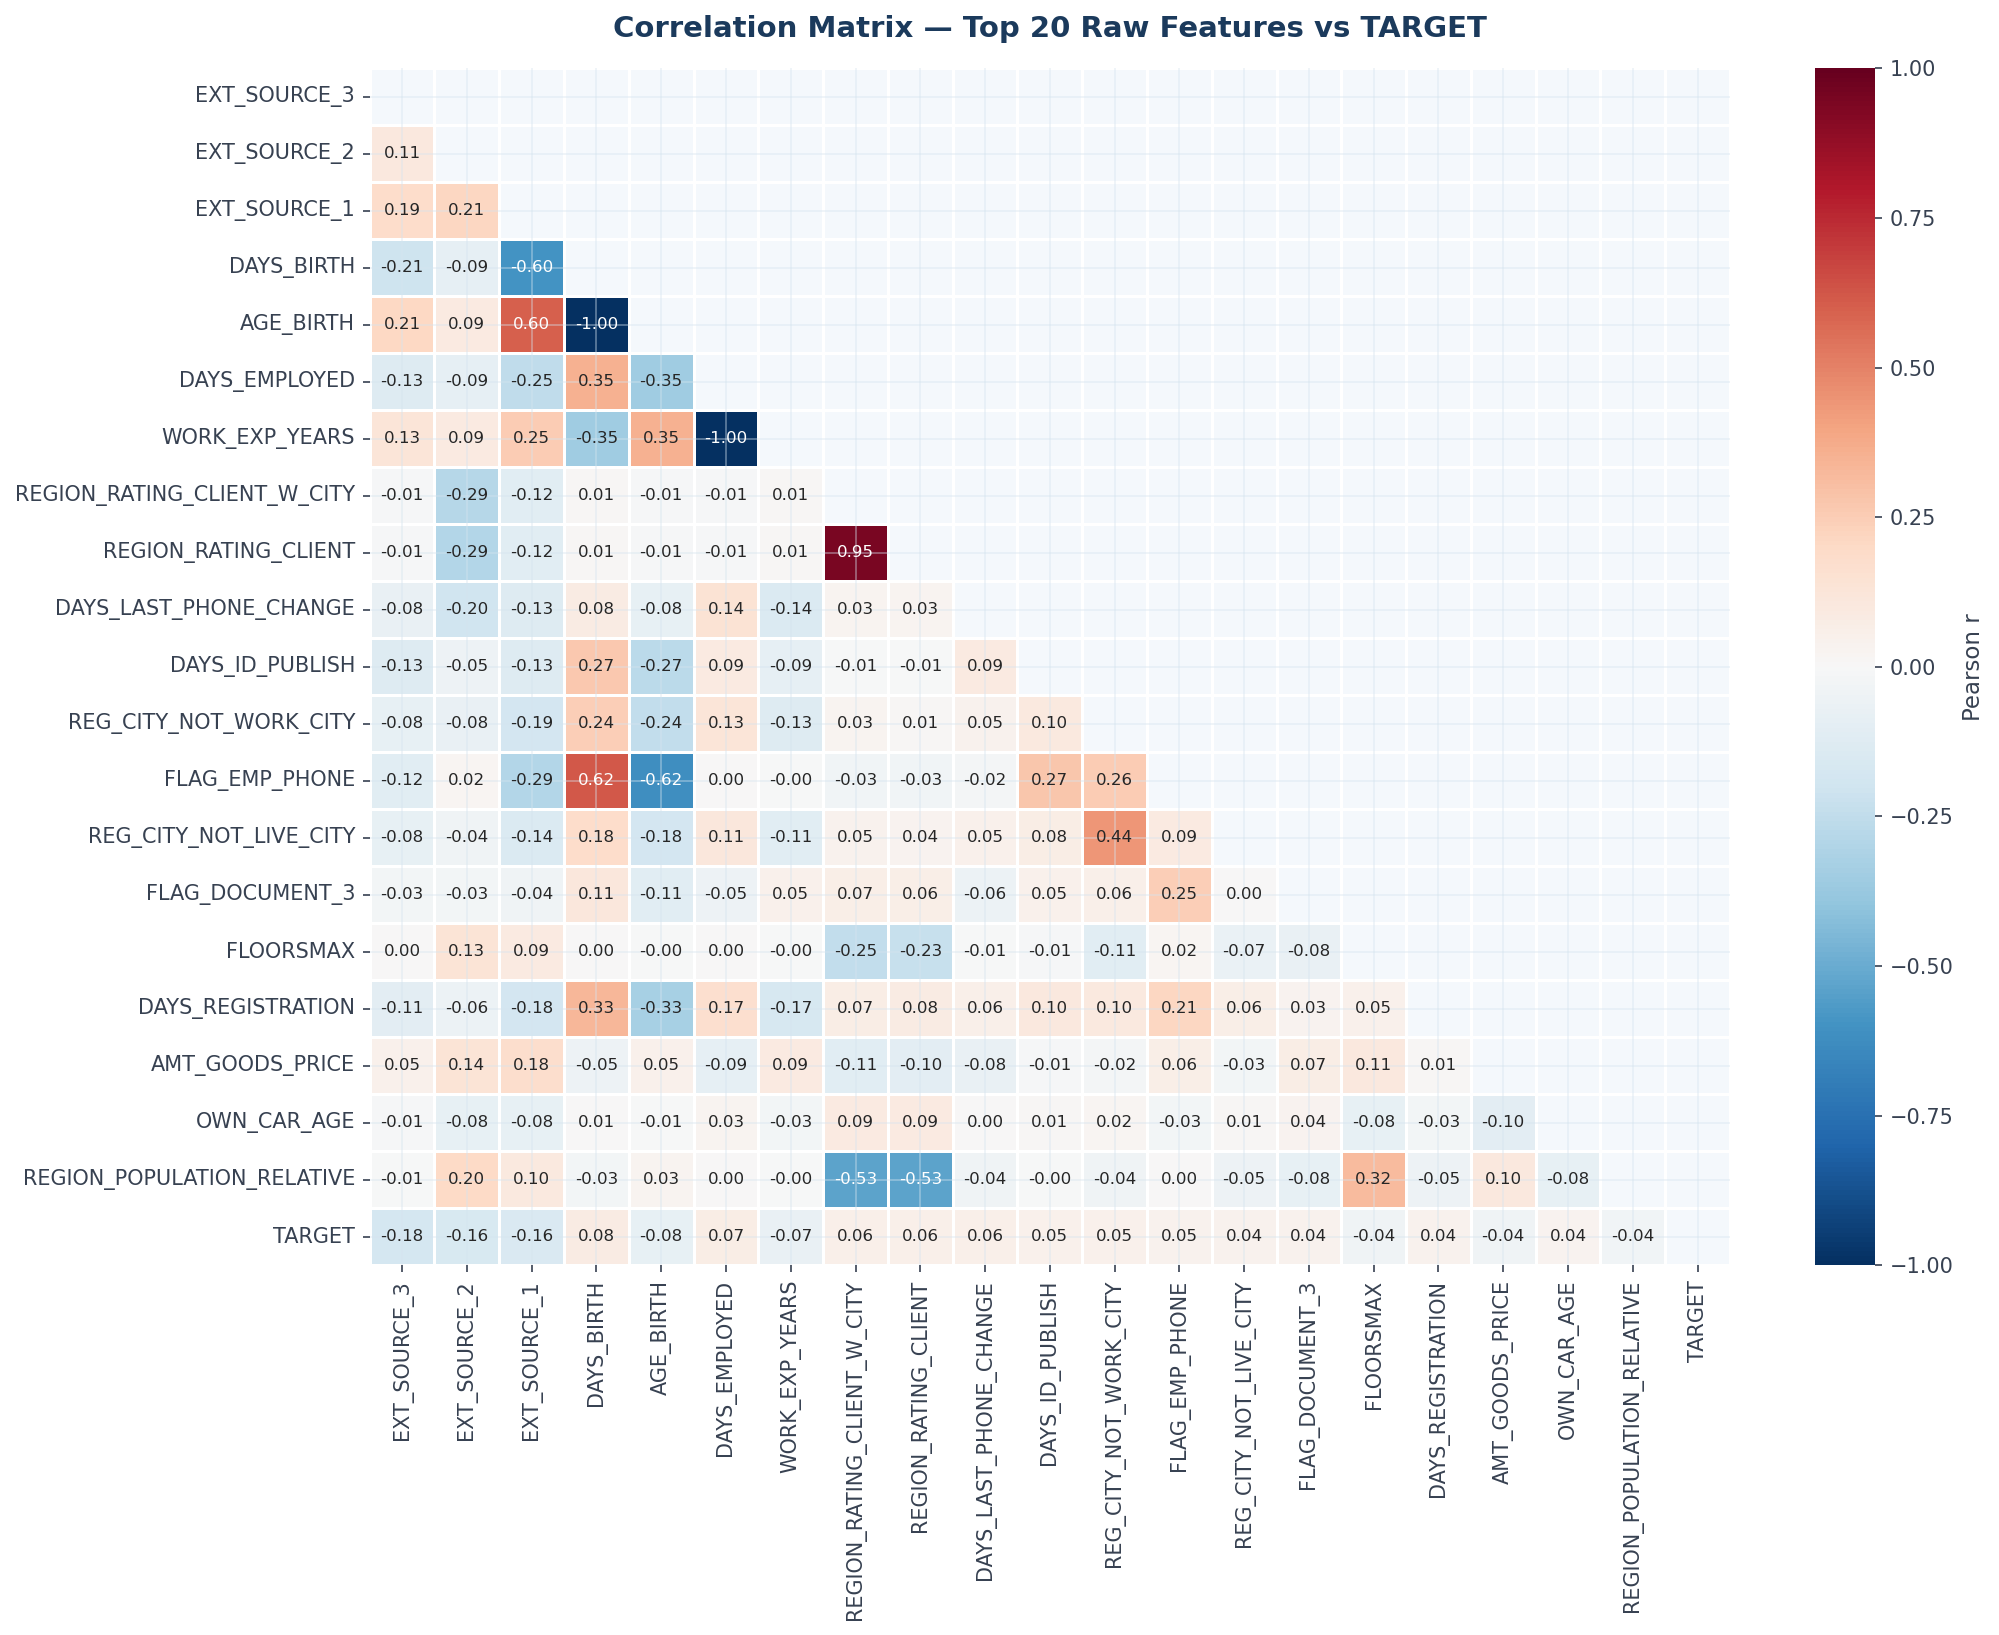

Top 10 raw correlations with TARGET:
EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
DAYS_BIRTH                     0.078239
AGE_BIRTH                      0.078234
DAYS_EMPLOYED                  0.074958
WORK_EXP_YEARS                 0.074958
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218


In [15]:
num_cols = [c for c in eda_df.select_dtypes(include=[np.number]).columns
            if c != 'SK_ID_CURR']
corr_tgt = eda_df[num_cols].corr()['TARGET'].drop('TARGET')
top20    = corr_tgt.abs().nlargest(20).index.tolist() + ['TARGET']
corr_mat = eda_df[top20].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8},
    vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'}
)
ax.set_title('Correlation Matrix — Top 20 Raw Features vs TARGET')
plt.tight_layout()
plt.savefig('eda_correlation_raw.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 10 raw correlations with TARGET:')
print(corr_tgt.abs().nlargest(10).to_string())


In [16]:
def feature_engineering(df, bureau_df=None):
    """
    Build all domain-informed features.

    Parameters
    ----------
    df        : cleaned application DataFrame (train or test snapshot)
    bureau_df : optional bureau.csv DataFrame; if None, bureau columns are NaN

    Returns
    -------
    DataFrame with original columns PLUS all engineered features.
    Always produces the same column set regardless of bureau_df presence.
    """
    df = df.copy()

    # ── Age ──────────────────────────────────────────────────────────────
    df['AGE_YEARS']     = (-df['DAYS_BIRTH']) / 365.25
    df['AGE_BUCKET']    = (
        pd.cut(df['AGE_YEARS'], bins=[0, 25, 30, 40, 50, 60, 100],
               labels=[0, 1, 2, 3, 4, 5])
        .astype(float).fillna(2)
    )
    df['IS_YOUNG'] = (df['AGE_YEARS'] < 30).astype(int)

    # ── Employment ───────────────────────────────────────────────────────
    df['YEARS_EMPLOYED']     = (-df['DAYS_EMPLOYED'].clip(upper=0)) / 365.25
    df['IS_UNEMPLOYED']      = df['DAYS_EMPLOYED'].isna().astype(int)
    df['EMPLOYMENT_TO_AGE']  = df['YEARS_EMPLOYED'] / (df['AGE_YEARS'] + 1)
    df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED']  / (df['DAYS_BIRTH'] + 1)

    # ── Financial ratios ─────────────────────────────────────────────────
    df['CREDIT_TO_INCOME']  = df['AMT_CREDIT']       / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_TO_INCOME'] = df['AMT_ANNUITY']      / (df['AMT_INCOME_TOTAL'] + 1)
    df['CREDIT_TO_GOODS']   = df['AMT_CREDIT']       / (df['AMT_GOODS_PRICE']  + 1)
    df['ANNUITY_TO_CREDIT'] = df['AMT_ANNUITY']      / (df['AMT_CREDIT']       + 1)
    df['CREDIT_TERM']       = df['AMT_CREDIT']       / (df['AMT_ANNUITY']      + 1)
    df['PAYMENT_RATE']      = df['AMT_ANNUITY']      / (df['AMT_CREDIT']       + 1)
    df['GOODS_CREDIT_DIFF'] = df['AMT_CREDIT']        - df['AMT_GOODS_PRICE']
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] /  df['CNT_FAM_MEMBERS'].clip(lower=1)
    df['CHILDREN_RATIO']    = df['CNT_CHILDREN']     / (df['CNT_FAM_MEMBERS'] + 1)

    # ── Occupation group ─────────────────────────────────────────────────
    if 'OCCUPATION_TYPE' in df.columns:
        df['OCCUPATION_GROUP'] = df['OCCUPATION_TYPE'].map(occupation_group)

    # ── EXT_SOURCE composites ─────────────────────────────────────────────
    ext = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
           if c in df.columns]
    if ext:
        df['EXT_MEAN']     = df[ext].mean(axis=1)
        df['EXT_MIN']      = df[ext].min(axis=1)
        df['EXT_MAX']      = df[ext].max(axis=1)
        df['EXT_STD']      = df[ext].std(axis=1)
        df['EXT_PROD']     = df[ext].prod(axis=1)
        weights            = {'EXT_SOURCE_1': 1, 'EXT_SOURCE_2': 3, 'EXT_SOURCE_3': 2}
        total_w            = sum(weights[c] for c in ext)
        df['EXT_WEIGHTED'] = sum(df[c] * weights[c] for c in ext) / total_w
        if 'EXT_SOURCE_2' in df.columns:
            df['EXT2_x_INCOME'] = df['EXT_SOURCE_2'] * df['AMT_INCOME_TOTAL'] / 1e5
            df['EXT2_x_CREDIT'] = df['EXT_SOURCE_2'] * df['AMT_CREDIT']       / 1e5
            df['EXT2_x_AGE']    = df['EXT_SOURCE_2'] * df['AGE_YEARS']

    # ── Credit bureau request counts ──────────────────────────────────────
    req_cols = [c for c in df.columns if 'AMT_REQ_CREDIT_BUREAU' in c]
    if req_cols:
        df['TOTAL_CREDIT_REQS'] = df[req_cols].sum(axis=1)

    # ── Document count ────────────────────────────────────────────────────
    doc_cols = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
    if doc_cols:
        df['TOTAL_DOCS'] = df[doc_cols].sum(axis=1)

    # ── Bureau aggregates ─────────────────────────────────────────────────
    bureau_agg_cols = [
        'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS', 'BUREAU_CLOSED_LOANS',
        'BUREAU_AMT_CREDIT_SUM', 'BUREAU_AMT_ANNUITY_SUM', 'BUREAU_MAX_OVERDUE',
        'BUREAU_DAYS_CREDIT_MAX', 'BUREAU_ACTIVE_RATIO', 'TOTAL_ANNUITY', 'DTI',
    ]
    if bureau_df is not None:
        bur = bureau_df.copy()
        bur['AMT_ANNUITY_ACTIVE'] = np.where(
            bur['CREDIT_ACTIVE'] == 'Closed', 0, bur['AMT_ANNUITY']
        )
        bur_agg = bur.groupby('SK_ID_CURR').agg(
            BUREAU_LOAN_COUNT      = ('SK_ID_BUREAU',          'count'),
            BUREAU_ACTIVE_LOANS    = ('CREDIT_ACTIVE',         lambda x: (x == 'Active').sum()),
            BUREAU_CLOSED_LOANS    = ('CREDIT_ACTIVE',         lambda x: (x == 'Closed').sum()),
            BUREAU_AMT_CREDIT_SUM  = ('AMT_CREDIT_SUM',        'sum'),
            BUREAU_AMT_ANNUITY_SUM = ('AMT_ANNUITY_ACTIVE',    'sum'),
            BUREAU_MAX_OVERDUE     = ('AMT_CREDIT_MAX_OVERDUE','max'),
            BUREAU_DAYS_CREDIT_MAX = ('DAYS_CREDIT',           'max'),
        ).reset_index()
        bur_agg['BUREAU_ACTIVE_RATIO'] = (
            bur_agg['BUREAU_ACTIVE_LOANS']
            / bur_agg['BUREAU_LOAN_COUNT'].clip(lower=1)
        )
        df = df.merge(bur_agg, on='SK_ID_CURR', how='left')
        df['TOTAL_ANNUITY'] = df['AMT_ANNUITY'] + df['BUREAU_AMT_ANNUITY_SUM'].fillna(0)
        df['DTI']           = (df['TOTAL_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)) * 100
    else:
        for col in bureau_agg_cols:
            df[col] = np.nan

    return df


train_fe = feature_engineering(TRAIN_CLEAN_SNAPSHOT, bureau_credit)
test_fe  = feature_engineering(TEST_CLEAN_SNAPSHOT,  bureau_credit)

new_feats = sorted(set(train_fe.columns) - set(TRAIN_CLEAN_SNAPSHOT.columns) - {'TARGET'})
print(f'✅ Feature engineering complete.')
print(f'   Columns: {TRAIN_CLEAN_SNAPSHOT.shape[1]} → {train_fe.shape[1]} '
      f'(+{len(new_feats)} new)')

# Column parity check
only_train = set(train_fe.columns) - {'TARGET'} - set(test_fe.columns)
only_test  = set(test_fe.columns) - set(train_fe.columns)
print(f'   Only in train : {only_train or "none ✅"}')
print(f'   Only in test  : {only_test  or "none ✅"}')


✅ Feature engineering complete.
   Columns: 120 → 158 (+38 new)
   Only in train : none ✅
   Only in test  : none ✅


In [18]:
TARGET_ENCODE_COLS = [
    'ORGANIZATION_TYPE', 'OCCUPATION_TYPE', 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE', 'OCCUPATION_GROUP',
]
TARGET_ENCODE_COLS = [c for c in TARGET_ENCODE_COLS if c in train_fe.columns]

SMOOTHING_K = 20
N_FOLDS     = 5
global_mean = train_fe['TARGET'].mean()
te_maps     = {}

train_te = train_fe.copy()
test_te  = test_fe.copy()

kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for col in TARGET_ENCODE_COLS:
    new_col = col + '_TE'
    train_te[new_col] = np.nan

    for _, (trn_idx, val_idx) in enumerate(kf.split(train_te, train_te['TARGET'])):
        fold_map = (
            train_te['TARGET'].iloc[trn_idx]
            .groupby(train_te[col].iloc[trn_idx])
            .agg(['mean', 'count'])
        )
        fold_map['smoothed'] = (
            (fold_map['count'] * fold_map['mean'] + SMOOTHING_K * global_mean)
            / (fold_map['count'] + SMOOTHING_K)
        )
        train_te.loc[train_te.index[val_idx], new_col] = (
            train_te[col].iloc[val_idx].map(fold_map['smoothed'])
        )
    train_te[new_col].fillna(global_mean, inplace=True)

    # Full-data map for the test set
    gmap = train_te['TARGET'].groupby(train_te[col]).agg(['mean', 'count'])
    gmap['smoothed'] = (
        (gmap['count'] * gmap['mean'] + SMOOTHING_K * global_mean)
        / (gmap['count'] + SMOOTHING_K)
    )
    te_maps[col]      = gmap['smoothed']
    test_te[new_col]  = test_te[col].map(gmap['smoothed']).fillna(global_mean)
    print(f'  ✅ {col:35s} → {new_col}')

train_te.drop(columns=TARGET_ENCODE_COLS, inplace=True, errors='ignore')
test_te.drop(columns=TARGET_ENCODE_COLS,  inplace=True, errors='ignore')
print(f'\nTrain : {train_te.shape}  |  Test : {test_te.shape}')


  ✅ ORGANIZATION_TYPE                   → ORGANIZATION_TYPE_TE
  ✅ OCCUPATION_TYPE                     → OCCUPATION_TYPE_TE
  ✅ NAME_INCOME_TYPE                    → NAME_INCOME_TYPE_TE
  ✅ NAME_EDUCATION_TYPE                 → NAME_EDUCATION_TYPE_TE
  ✅ OCCUPATION_GROUP                    → OCCUPATION_GROUP_TE

Train : (307511, 158)  |  Test : (48744, 157)


In [23]:
TARGET    = train_te['TARGET']
TRAIN_IDS = train_te['SK_ID_CURR']
TEST_IDS  = test_te['SK_ID_CURR']

train_df = train_te.drop(columns=['TARGET', 'SK_ID_CURR'])
test_df  = test_te.drop(columns=['SK_ID_CURR'], errors='ignore')

# Align object columns between train and test
train_obj = set(train_df.select_dtypes('object').columns)
test_obj  = set(test_df.select_dtypes('object').columns)
for col in train_obj - test_obj:
    test_df[col]  = 'UNKNOWN'
for col in test_obj - train_obj:
    train_df[col] = 'UNKNOWN'

# Label-encode remaining object columns (flag / binary categoricals)
cat_cols = sorted(train_df.select_dtypes('object').columns)
le = LabelEncoder()
for col in cat_cols:
    combined = (
        pd.concat([train_df[col], test_df[col]])
        .fillna('UNKNOWN').astype(str)
    )
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].fillna('UNKNOWN').astype(str))
    test_df[col]  = le.transform(test_df[col].fillna('UNKNOWN').astype(str))

# Keep only common columns
common_cols = [c for c in train_df.columns if c in test_df.columns]
train_df    = train_df[common_cols]
test_df     = test_df[common_cols]

# Median imputation (fit on train only — no leakage)
imputer       = SimpleImputer(strategy='median')
train_imputed = pd.DataFrame(
    imputer.fit_transform(train_df), columns=train_df.columns
)
test_imputed  = pd.DataFrame(
    imputer.transform(test_df), columns=test_df.columns
)

FEAT_NAMES = list(train_df.columns)
print(f'✅ Final feature set : {len(FEAT_NAMES)} columns')
print(f'   NaN remaining     : {train_imputed.isnull().sum().sum()}')


✅ Final feature set : 156 columns
   NaN remaining     : 0


In [24]:
X = train_imputed.values
y = TARGET.values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train : {X_train.shape}  |  X_val : {X_val.shape}')
print(f'Train PD: {y_train.mean():.3f}  |  Val PD: {y_val.mean():.3f}')

# Standard scaling (used for LR and NN only)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(test_imputed.values)

# Imbalance weights
neg, pos         = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f'\nscale_pos_weight (XGBoost) : {scale_pos_weight:.2f}')

# SMOTE for LR / DT / RF
sm = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_sm,    y_train_sm    = sm.fit_resample(X_train,    y_train)
X_train_sm_sc, y_train_sm_sc = sm.fit_resample(X_train_sc, y_train)
print(f'Before SMOTE : {np.bincount(y_train)}')
print(f'After  SMOTE : {np.bincount(y_train_sm)}')


X_train : (246008, 156)  |  X_val : (61503, 156)
Train PD: 0.081  |  Val PD: 0.081

scale_pos_weight (XGBoost) : 11.39
Before SMOTE : [226148  19860]
After  SMOTE : [226148  67844]


In [25]:
results    = {}  # hold-out metrics keyed by model name
cv_results = {}  # cross-validation AUC per fold
roc_data   = {}  # (fpr, tpr, auc) for ROC plot

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def optimal_threshold(y_true, y_prob):
    """Return the probability threshold that maximises F1 on the P-R curve."""
    precs, recs, thrs = precision_recall_curve(y_true, y_prob)
    f1s = 2 * (precs * recs) / (precs + recs + 1e-9)
    return float(thrs[f1s[:-1].argmax()])


def record_holdout(name, y_prob, y_true, elapsed, threshold=None):
    """Compute and store all hold-out metrics at the optimal threshold."""
    thr    = threshold if threshold is not None else optimal_threshold(y_true, y_prob)
    y_pred = (y_prob >= thr).astype(int)
    auc    = roc_auc_score(y_true, y_prob)
    ap     = average_precision_score(y_true, y_prob)
    results[name] = {
        'AUC-ROC'   : auc,
        'Avg-Prec'  : ap,
        'Threshold' : round(thr, 4),
        'F1'        : f1_score(y_true, y_pred, zero_division=0),
        'Precision' : precision_score(y_true, y_pred, zero_division=0),
        'Recall'    : recall_score(y_true, y_pred, zero_division=0),
        'Accuracy'  : accuracy_score(y_true, y_pred),
        'Time(s)'   : round(elapsed, 1),
    }
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_data[name] = (fpr, tpr, auc)
    print(f'  AUC: {auc:.4f} | AP: {ap:.4f} | F1: {results[name]["F1"]:.4f} '
          f'| Thr: {thr:.3f} | {elapsed:.1f}s')
    return thr


def cross_validate_model(name, build_fn, X_cv, y_cv, use_smote=False):
    """Run 5-fold stratified CV; return (mean_auc, std_auc)."""
    fold_aucs = []
    for fold, (tr_idx, va_idx) in enumerate(SKF.split(X_cv, y_cv), 1):
        X_tr, X_va = X_cv[tr_idx], X_cv[va_idx]
        y_tr, y_va = y_cv[tr_idx], y_cv[va_idx]
        if use_smote:
            sm_fold = SMOTE(random_state=42, sampling_strategy=0.3)
            X_tr, y_tr = sm_fold.fit_resample(X_tr, y_tr)
        m = build_fn()
        m.fit(X_tr, y_tr)
        fold_aucs.append(roc_auc_score(y_va, m.predict_proba(X_va)[:, 1]))
    mu, sd = np.mean(fold_aucs), np.std(fold_aucs)
    cv_results[name] = {'fold_aucs': fold_aucs, 'mean': mu, 'std': sd}
    print(f'  CV AUC: {mu:.4f} ± {sd:.4f}  '
        f'(folds: {[round(a, 4) for a in fold_aucs]})')
    return mu, sd


print('✅ CV infrastructure ready.')


✅ CV infrastructure ready.


In [26]:
print('── Logistic Regression — 5-fold CV ──')
cross_validate_model(
    'Logistic Regression',
    lambda: LogisticRegression(
        max_iter=1000, class_weight='balanced', C=0.1, random_state=42, n_jobs=-1
    ),
    X_train_sm_sc, y_train_sm,
)

print('\n── Logistic Regression — hold-out ──')
start = time.time()
lr = LogisticRegression(
    max_iter=1000, class_weight='balanced', C=0.1, random_state=42, n_jobs=-1
)
lr.fit(X_train_sm_sc, y_train_sm)
y_prob_lr = lr.predict_proba(X_val_sc)[:, 1]
lr_thr = record_holdout('Logistic Regression', y_prob_lr, y_val, time.time() - start)


── Logistic Regression — 5-fold CV ──
  CV AUC: 0.7706 ± 0.0011  (folds: [np.float64(0.772), np.float64(0.7697), np.float64(0.7718), np.float64(0.7701), np.float64(0.7695)])

── Logistic Regression — hold-out ──
  AUC: 0.7527 | AP: 0.2387 | F1: 0.3055 | Thr: 0.687 | 25.2s


In [27]:
print('── Decision Tree — 5-fold CV ──')
cross_validate_model(
    'Decision Tree',
    lambda: DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=50, class_weight='balanced', random_state=42
    ),
    X_train_sm, y_train_sm,
)

print('\n── Decision Tree — hold-out ──')
start = time.time()
dt = DecisionTreeClassifier(
    max_depth=8, min_samples_leaf=50, class_weight='balanced', random_state=42
)
dt.fit(X_train_sm, y_train_sm)
y_prob_dt = dt.predict_proba(X_val)[:, 1]
dt_thr = record_holdout('Decision Tree', y_prob_dt, y_val, time.time() - start)


── Decision Tree — 5-fold CV ──
  CV AUC: 0.8814 ± 0.0013  (folds: [np.float64(0.8835), np.float64(0.8803), np.float64(0.8823), np.float64(0.881), np.float64(0.8799)])

── Decision Tree — hold-out ──
  AUC: 0.7158 | AP: 0.1733 | F1: 0.2670 | Thr: 0.458 | 52.6s


In [28]:
print('── Random Forest — 5-fold CV ──')
cross_validate_model(
    'Random Forest',
    lambda: RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=30,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    X_train_sm, y_train_sm,
)

print('\n── Random Forest — hold-out ──')
start = time.time()
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=30,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
y_prob_rf = rf.predict_proba(X_val)[:, 1]
rf_thr = record_holdout('Random Forest', y_prob_rf, y_val, time.time() - start)


── Random Forest — 5-fold CV ──
  CV AUC: 0.9207 ± 0.0014  (folds: [np.float64(0.9232), np.float64(0.9193), np.float64(0.9201), np.float64(0.921), np.float64(0.9198)])

── Random Forest — hold-out ──
  AUC: 0.7395 | AP: 0.2074 | F1: 0.2867 | Thr: 0.436 | 152.4s


In [29]:
def build_xgb():
    """Return a fresh XGBClassifier with standard CV hyperparameters."""
    return XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        min_child_weight=5, subsample=0.75,
        colsample_bytree=0.75, colsample_bylevel=0.75,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc', random_state=42,
        n_jobs=-1, tree_method='hist', verbosity=0,
    )


print('── XGBoost — 5-fold CV ──')
fold_aucs_xgb = []
for fold, (tr_idx, va_idx) in enumerate(SKF.split(X_train, y_train), 1):
    Xf_tr, Xf_va = X_train[tr_idx], X_train[va_idx]
    yf_tr, yf_va = y_train[tr_idx], y_train[va_idx]
    m = build_xgb()
    m.fit(Xf_tr, yf_tr, eval_set=[(Xf_va, yf_va)], verbose=False)
    fold_aucs_xgb.append(roc_auc_score(yf_va, m.predict_proba(Xf_va)[:, 1]))
    print(f'  Fold {fold}: AUC = {fold_aucs_xgb[-1]:.4f}')

cv_results['XGBoost'] = {
    'fold_aucs': fold_aucs_xgb,
    'mean': np.mean(fold_aucs_xgb),
    'std':  np.std(fold_aucs_xgb),
}
print(f'  CV AUC: {np.mean(fold_aucs_xgb):.4f} ± {np.std(fold_aucs_xgb):.4f}')

print('\n── XGBoost — final fit with early stopping ──')
start = time.time()
xgb_model = XGBClassifier(
    n_estimators=1000, learning_rate=0.02, max_depth=5,
    min_child_weight=5, subsample=0.75,
    colsample_bytree=0.75, colsample_bylevel=0.75,
    reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc', early_stopping_rounds=50,
    random_state=42, n_jobs=-1, tree_method='hist',
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]
xgb_thr    = record_holdout('XGBoost', y_prob_xgb, y_val, time.time() - start)
y_pred_xgb = (y_prob_xgb >= xgb_thr).astype(int)


── XGBoost — 5-fold CV ──
  Fold 1: AUC = 0.7670
  Fold 2: AUC = 0.7652
  Fold 3: AUC = 0.7661
  Fold 4: AUC = 0.7676
  Fold 5: AUC = 0.7653
  CV AUC: 0.7662 ± 0.0009

── XGBoost — final fit with early stopping ──
[0]	validation_0-auc:0.72358
[100]	validation_0-auc:0.74962
[200]	validation_0-auc:0.75966
[300]	validation_0-auc:0.76478
[400]	validation_0-auc:0.76743
[500]	validation_0-auc:0.76909
[600]	validation_0-auc:0.77029
[700]	validation_0-auc:0.77120
[800]	validation_0-auc:0.77198
[900]	validation_0-auc:0.77273
[999]	validation_0-auc:0.77326
  AUC: 0.7733 | AP: 0.2657 | F1: 0.3220 | Thr: 0.662 | 111.8s


In [30]:
INPUT_DIM = X_train_sc.shape[1]


def build_nn(input_dim, dropout=0.30):
    """Return a compiled Keras Sequential model for binary credit classification."""
    m = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(dropout),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(dropout),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(), layers.Dropout(dropout * 0.8),
        layers.Dense(64,  activation='relu'),
        layers.Dropout(dropout * 0.5),
        layers.Dense(1, activation='sigmoid'),
    ], name='CreditDefaultNet')
    m.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), 'accuracy'],
    )
    return m


# Class weights for imbalance handling
cw_arr = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
cw = {0: float(cw_arr[0]), 1: float(cw_arr[1])}

print('── Neural Network — 5-fold CV ──')
fold_aucs_nn = []
for fold, (tr_idx, va_idx) in enumerate(SKF.split(X_train_sc, y_train), 1):
    Xf_tr, Xf_va = X_train_sc[tr_idx], X_train_sc[va_idx]
    yf_tr, yf_va = y_train[tr_idx],    y_train[va_idx]
    m = build_nn(INPUT_DIM)
    cb_es = callbacks.EarlyStopping(
        monitor='val_auc', patience=5, restore_best_weights=True, mode='max'
    )
    m.fit(Xf_tr, yf_tr, validation_data=(Xf_va, yf_va),
          epochs=30, batch_size=2048, class_weight=cw,
          callbacks=[cb_es], verbose=0)
    fold_aucs_nn.append(
        roc_auc_score(yf_va, m.predict(Xf_va, verbose=0).flatten())
    )
    print(f'  Fold {fold}: AUC = {fold_aucs_nn[-1]:.4f}')

cv_results['Neural Network'] = {
    'fold_aucs': fold_aucs_nn,
    'mean': np.mean(fold_aucs_nn),
    'std':  np.std(fold_aucs_nn),
}
print(f'  CV AUC: {np.mean(fold_aucs_nn):.4f} ± {np.std(fold_aucs_nn):.4f}')

print('\n── Neural Network — final fit ──')
nn = build_nn(INPUT_DIM)
nn.summary()
nn_cbs = [
    callbacks.EarlyStopping(
        monitor='val_auc', patience=10, restore_best_weights=True, mode='max'
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=5, mode='max', min_lr=1e-6
    ),
    callbacks.ModelCheckpoint(
        'best_nn.keras', monitor='val_auc', save_best_only=True, mode='max'
    ),
]
start = time.time()
hist  = nn.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=100, batch_size=2048, class_weight=cw,
    callbacks=nn_cbs, verbose=1,
)
y_prob_nn = nn.predict(X_val_sc, verbose=0).flatten()
nn_thr    = record_holdout('Neural Network', y_prob_nn, y_val, time.time() - start)


── Neural Network — 5-fold CV ──
  Fold 1: AUC = 0.7545
  Fold 2: AUC = 0.7528
  Fold 3: AUC = 0.7592
  Fold 4: AUC = 0.7565
  Fold 5: AUC = 0.7522
  CV AUC: 0.7550 ± 0.0026

── Neural Network — final fit ──


Model: "CreditDefaultNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                     │ (None, 512)                 │          80,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 256,513 (1002.00 KB)

 Trainable params: 254,721 (995.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.6364 - auc: 0.6995 - loss: 0.7085 - val_accuracy: 0.6691 - val_auc: 0.7462 - val_loss: 0.6492 - learning_rate: 0.0010
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.6617 - auc: 0.7344 - loss: 0.6667 - val_accuracy: 0.6643 - val_auc: 0.7527 - val_loss: 0.6504 - learning_rate: 0.0010
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.6737 - auc: 0.7443 - loss: 0.6543 - val_accuracy: 0.6645 - val_auc: 0.7545 - val_loss: 0.6467 - learning_rate: 0.0010
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.6775 - auc: 0.7514 - loss: 0.6453 - val_accuracy: 0.6869 - val_auc: 0.7553 - val_loss: 0.6236 - learning_rate: 0.0010
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.6770 - auc: 0.7554 - loss: 0.6390 - val_accuracy: 0.6966 - val_auc: 0.7573 - val_loss: 0.6086 - learning_rate: 0.0010
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy

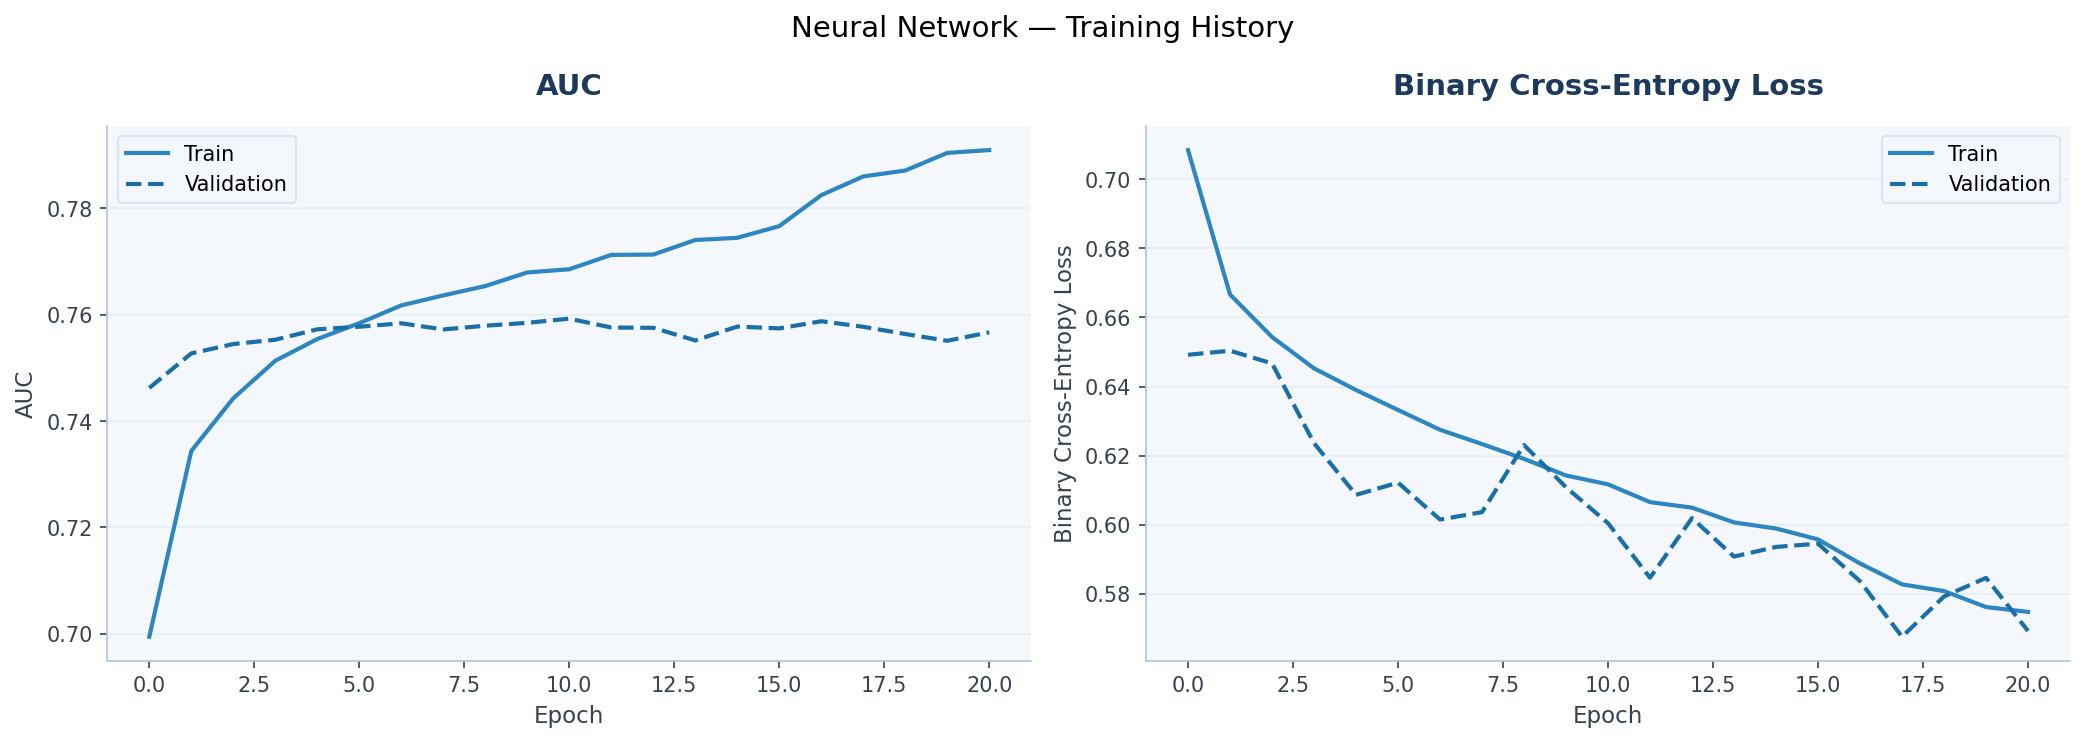

In [31]:
# ── Neural Network training curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neural Network — Training History', fontsize=14)

for ax, metric, title in zip(
    axes,
    [('auc', 'val_auc'), ('loss', 'val_loss')],
    ['AUC', 'Binary Cross-Entropy Loss']
):
    ax.plot(hist.history[metric[0]], color=C_STEEL, linewidth=2, label='Train')
    ax.plot(hist.history[metric[1]], color=C_BLUE_1,   linewidth=2,
            linestyle='--', label='Validation')
    ax.set_title(title)
    ax.legend()
    polish(ax, xlabel='Epoch', ylabel=title)

plt.tight_layout()
plt.savefig('nn_history.png', bbox_inches='tight', dpi=150)
plt.show()


In [32]:
# ── Cross-validation summary ─────────────────────────────────────────────
cv_df = pd.DataFrame({
    name: {
        'CV Mean AUC': round(v['mean'], 4),
        'CV Std AUC' : round(v['std'],  4),
        'CV Min AUC' : round(min(v['fold_aucs']), 4),
        'CV Max AUC' : round(max(v['fold_aucs']), 4),
    }
    for name, v in cv_results.items()
}).T.sort_values('CV Mean AUC', ascending=False)

print('5-Fold Stratified Cross-Validation — AUC Summary')
display(
    cv_df.style
    .background_gradient(subset=['CV Mean AUC'], cmap='Blues')
    .format('{:.4f}')
)

# ── Hold-out metrics ──────────────────────────────────────────────────────
final = pd.DataFrame(results).T.sort_values('AUC-ROC', ascending=False)
print('\nHold-out Set Metrics (optimal threshold per model)')
display(
    final.style
    .background_gradient(subset=['AUC-ROC', 'Avg-Prec', 'F1'], cmap='Blues')
    .format({'AUC-ROC': '{:.4f}', 'Avg-Prec': '{:.4f}',
             'Threshold': '{:.4f}', 'F1': '{:.4f}',
             'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'Accuracy': '{:.4f}', 'Time(s)': '{:.1f}'})
)

best_name = final.index[0]
print(f'\n🏆 Best model : {best_name} '
      f'| AUC = {final.iloc[0]["AUC-ROC"]:.4f}')


5-Fold Stratified Cross-Validation — AUC Summary


,CV Mean AUC,CV Std AUC,CV Min AUC,CV Max AUC
Random Forest,0.9207,0.0014,0.9193,0.9232
Decision Tree,0.8814,0.0013,0.8799,0.8835
Logistic Regression,0.7706,0.0011,0.7695,0.7720
XGBoost,0.7662,0.0009,0.7652,0.7676
Neural Network,0.7550,0.0026,0.7522,0.7592



Hold-out Set Metrics (optimal threshold per model)


,AUC-ROC,Avg-Prec,Threshold,F1,Precision,Recall,Accuracy,Time(s)
XGBoost,0.7733,0.2657,0.6620,0.3220,0.2586,0.4266,0.8550,111.8
Neural Network,0.7593,0.2500,0.6694,0.3112,0.2445,0.4282,0.8470,229.3
Logistic Regression,0.7527,0.2387,0.6867,0.3055,0.2462,0.4026,0.8523,25.2
Random Forest,0.7395,0.2074,0.4356,0.2867,0.2089,0.4572,0.8164,152.4
Decision Tree,0.7158,0.1733,0.4585,0.2670,0.2025,0.3917,0.8263,52.6



🏆 Best model : XGBoost | AUC = 0.7733


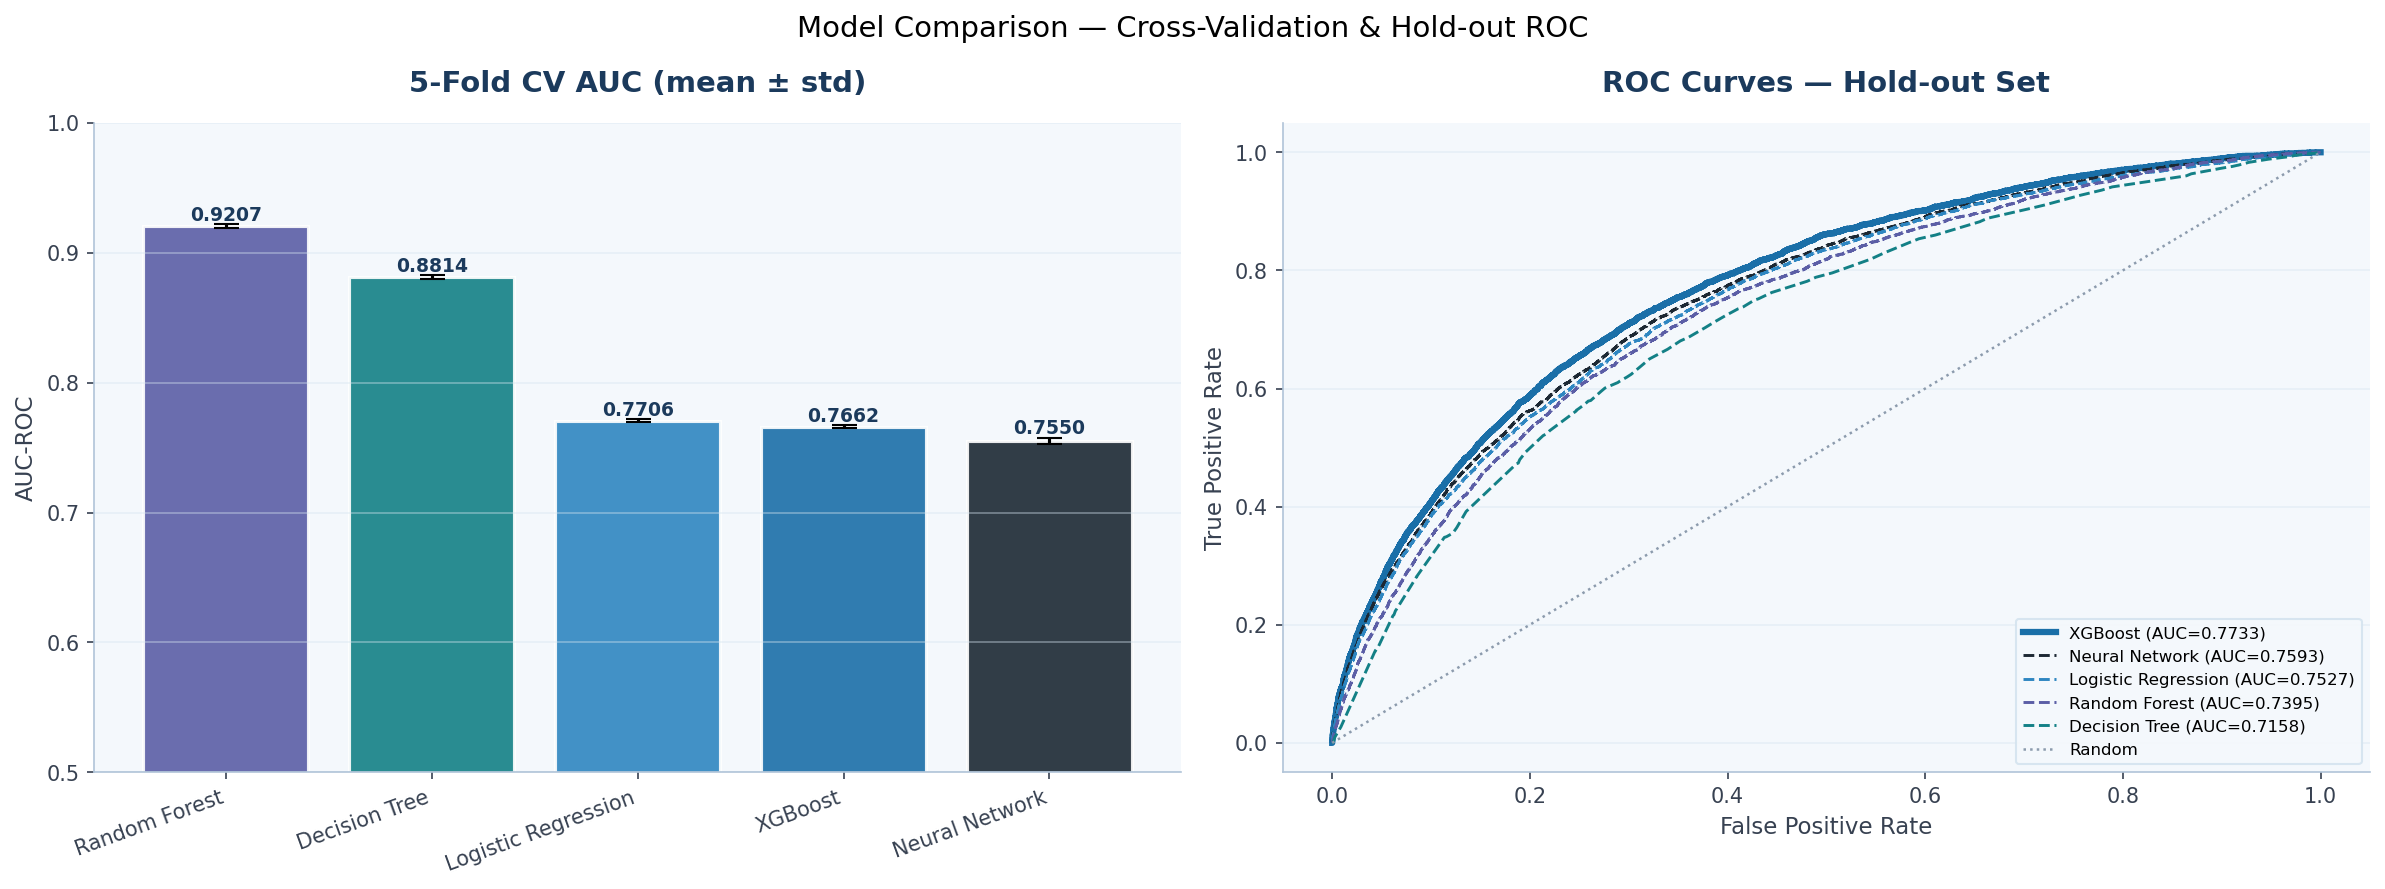

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison — Cross-Validation & Hold-out ROC', fontsize=14)

model_order = list(cv_df.index)
colors      = [MODEL_COLORS.get(m, C_PURPLE) for m in model_order]
means       = cv_df['CV Mean AUC'].values
stds        = cv_df['CV Std AUC'].values

# ── CV bar ────────────────────────────────────────────────────────────────
bars = axes[0].bar(
    model_order, means, yerr=stds, capsize=6,
    color=colors, edgecolor='white', linewidth=1.5, alpha=0.9
)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('5-Fold CV AUC (mean ± std)')
axes[0].set_xticklabels(model_order, rotation=20, ha='right')
polish(axes[0], ylabel='AUC-ROC')
for bar, mu, sd in zip(bars, means, stds):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + sd + 0.003,
        f'{mu:.4f}', ha='center', fontsize=9, fontweight='bold', color=C_NAVY
    )

# ── ROC curves ────────────────────────────────────────────────────────────
for name, (fpr, tpr, auc) in sorted(roc_data.items(), key=lambda x: -x[1][2]):
    lw = 3 if name == best_name else 1.4
    axes[1].plot(
        fpr, tpr,
        label=f'{name} (AUC={auc:.4f})',
        linewidth=lw,
        linestyle='-' if name == best_name else '--',
        color=MODEL_COLORS.get(name, C_PURPLE)
    )
axes[1].plot([0, 1], [0, 1], color=C_MID, linestyle=':', linewidth=1.2,
             label='Random')
polish(axes[1], xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[1].set_title('ROC Curves — Hold-out Set')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


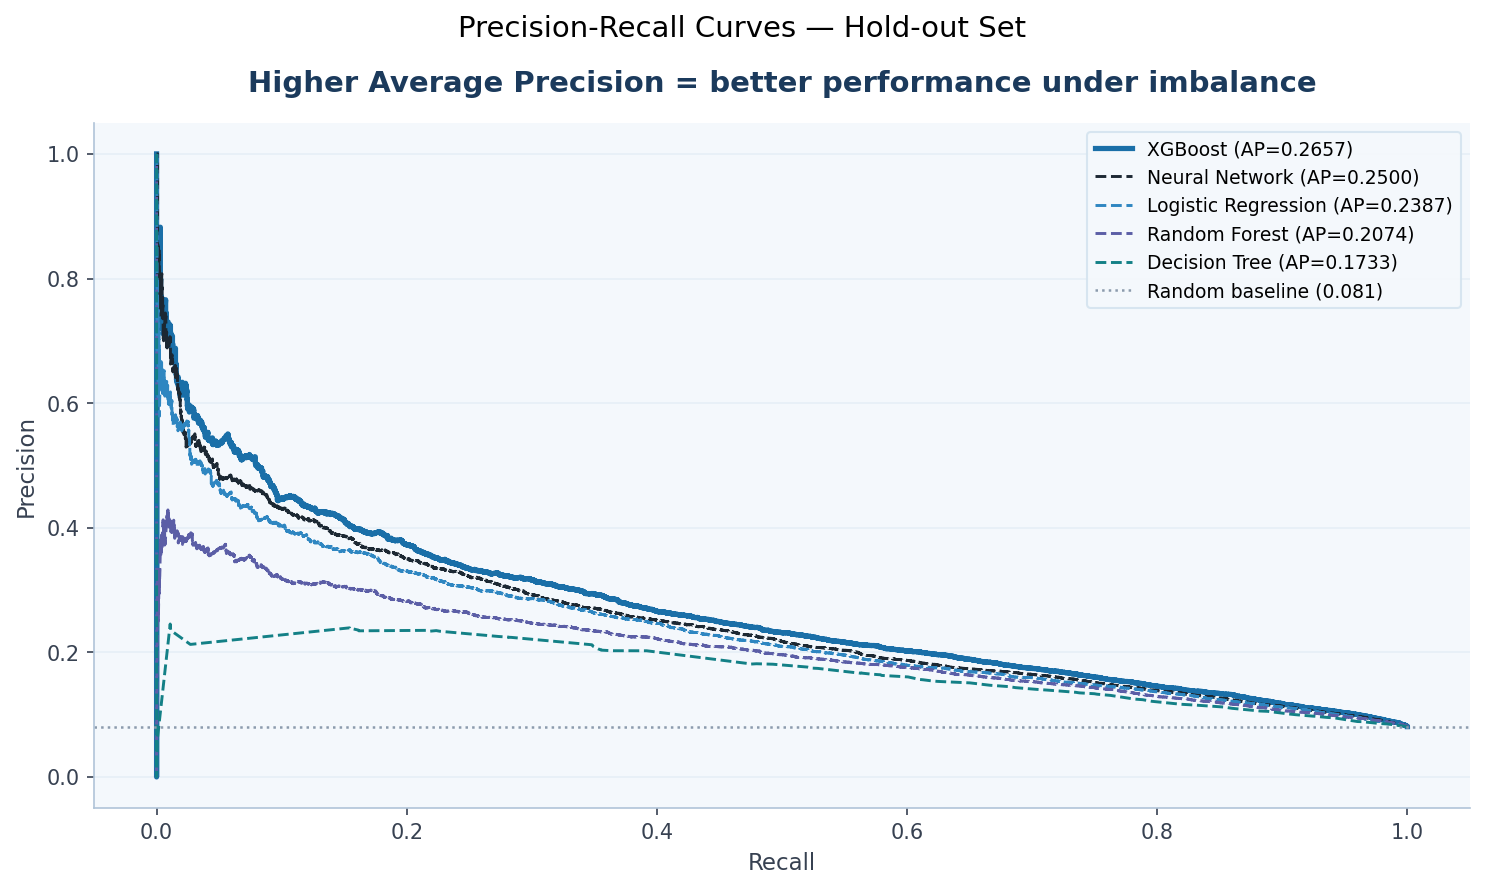

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Precision-Recall Curves — Hold-out Set', fontsize=14)

prob_map = {
    'Logistic Regression': y_prob_lr,
    'Decision Tree'      : y_prob_dt,
    'Random Forest'      : y_prob_rf,
    'XGBoost'            : y_prob_xgb,
    'Neural Network'     : y_prob_nn,
}
for name, probs in sorted(
    prob_map.items(),
    key=lambda x: -average_precision_score(y_val, x[1])
):
    ap    = average_precision_score(y_val, probs)
    p, r, _ = precision_recall_curve(y_val, probs)
    ax.plot(
        r, p,
        label=f'{name} (AP={ap:.4f})',
        linewidth=2.5 if name == best_name else 1.4,
        linestyle='-' if name == best_name else '--',
        color=MODEL_COLORS.get(name, C_PURPLE)
    )

baseline = y_val.mean()
ax.axhline(baseline, color=C_MID, linestyle=':', linewidth=1.2,
           label=f'Random baseline ({baseline:.3f})')
polish(ax, xlabel='Recall', ylabel='Precision')
ax.set_title('Higher Average Precision = better performance under imbalance')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', bbox_inches='tight', dpi=150)
plt.show()


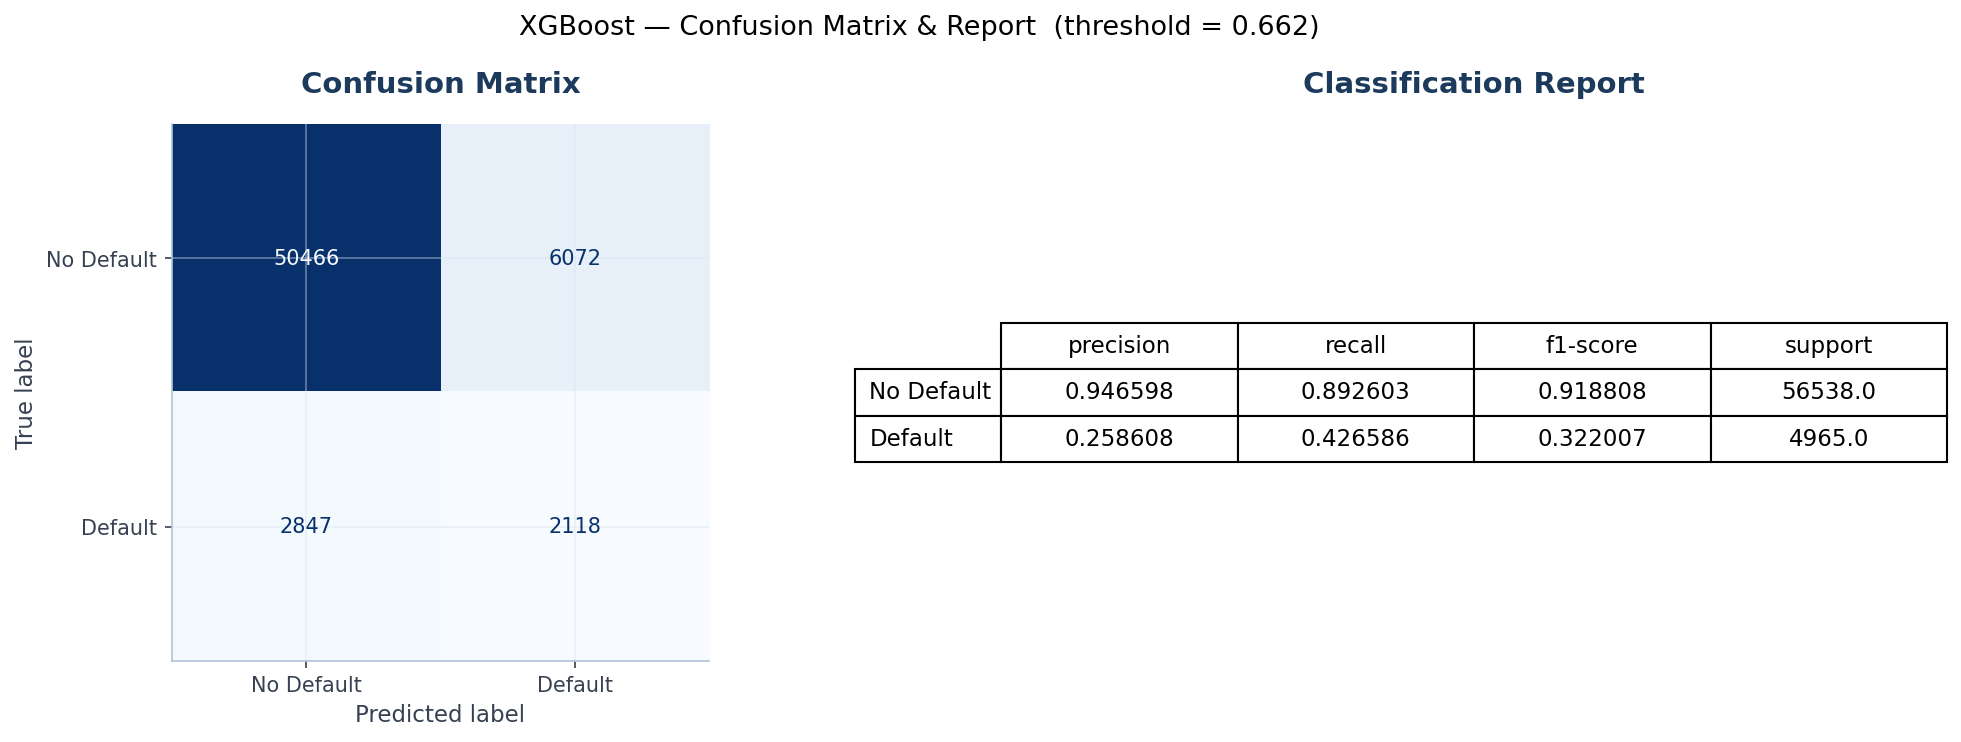

              precision    recall  f1-score   support

  No Default       0.95      0.89      0.92     56538
     Default       0.26      0.43      0.32      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.66      0.62     61503
weighted avg       0.89      0.85      0.87     61503



In [37]:
cm = confusion_matrix(y_val, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'XGBoost — Confusion Matrix & Report  (threshold = {xgb_thr:.3f})',
    fontsize=13
)

ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default']).plot(
    ax=axes[0], cmap='Blues', colorbar=False,
    values_format='d'
)
axes[0].set_title('Confusion Matrix')

report = classification_report(
    y_val, y_pred_xgb,
    target_names=['No Default', 'Default'],
    output_dict=True
)
rep_df = pd.DataFrame(report).T.iloc[:2]
axes[1].axis('off')
tbl = axes[1].table(
    cellText  = rep_df.round(6).values,
    rowLabels = rep_df.index,
    colLabels = rep_df.columns,
    cellLoc='center', loc='center',
)
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 2)
axes[1].set_title('Classification Report', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print(classification_report(y_val, y_pred_xgb,
                            target_names=['No Default', 'Default']))


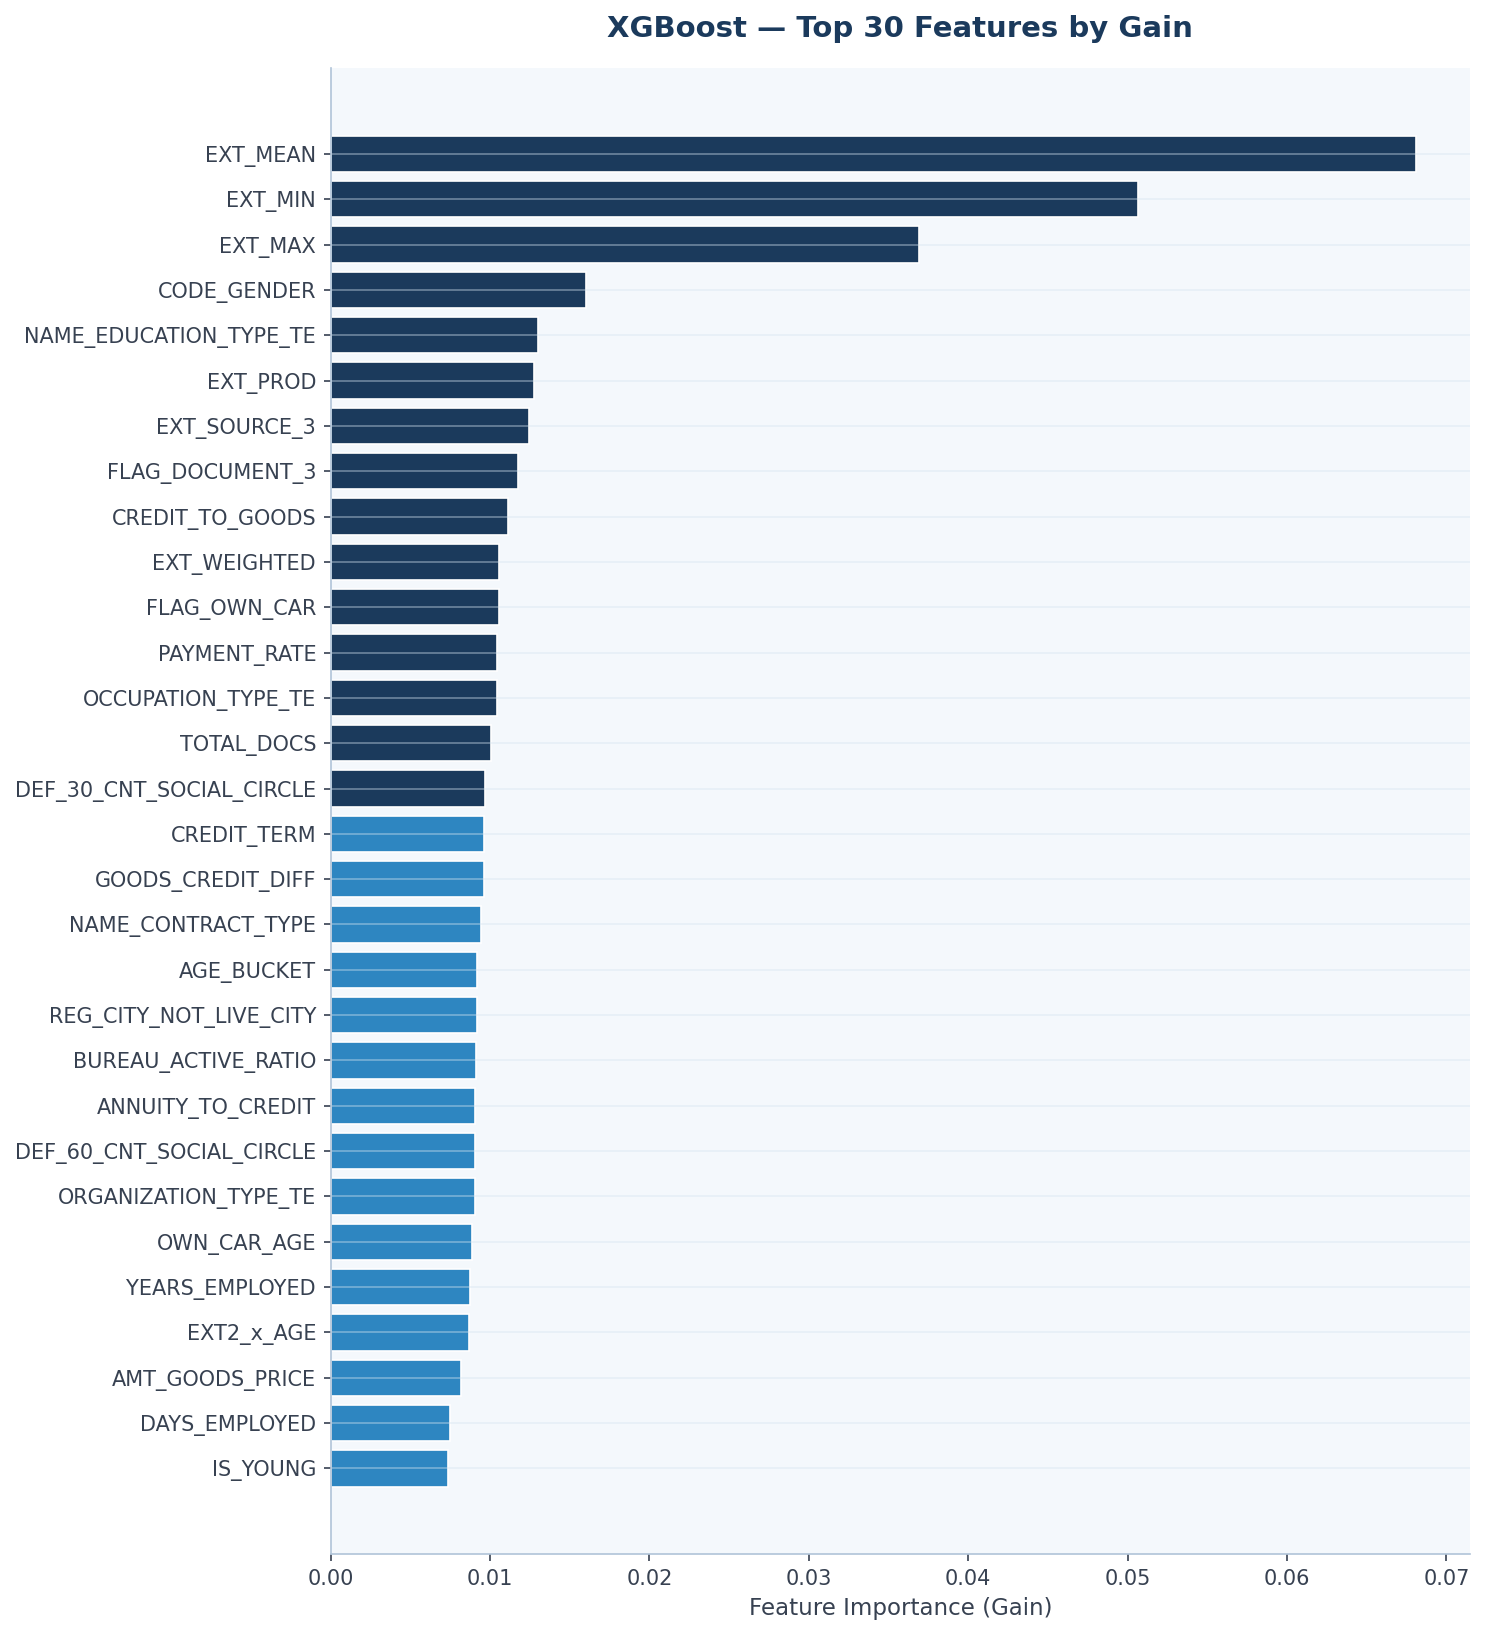

In [38]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEAT_NAMES)
top30    = feat_imp.nlargest(30).sort_values()

fig, ax = plt.subplots(figsize=(10, 11))
colors  = [C_STEEL if v < top30.median() else C_NAVY for v in top30.values]
ax.barh(top30.index, top30.values, color=colors,
        edgecolor='white', linewidth=0.8)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost — Top 30 Features by Gain')
polish(ax)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()


In [39]:
print('Building SHAP TreeExplainer (interventional, background = 1000 samples)...')
background  = shap.maskers.Independent(X_val, max_samples=1000)
explainer   = shap.TreeExplainer(
    xgb_model, data=background, feature_perturbation='interventional'
)

rng        = np.random.RandomState(42)
sample_idx = rng.choice(len(X_val), size=min(2000, len(X_val)), replace=False)
X_shap     = X_val[sample_idx]
y_shap     = y_val[sample_idx]

print('Computing SHAP values...')
shap_values = explainer(X_shap)
print(f'✅ SHAP values shape : {shap_values.values.shape}')


Building SHAP TreeExplainer (interventional, background = 1000 samples)...
Computing SHAP values...


100%|===================| 1999/2000 [16:57<00:00]        

✅ SHAP values shape : (2000, 156)


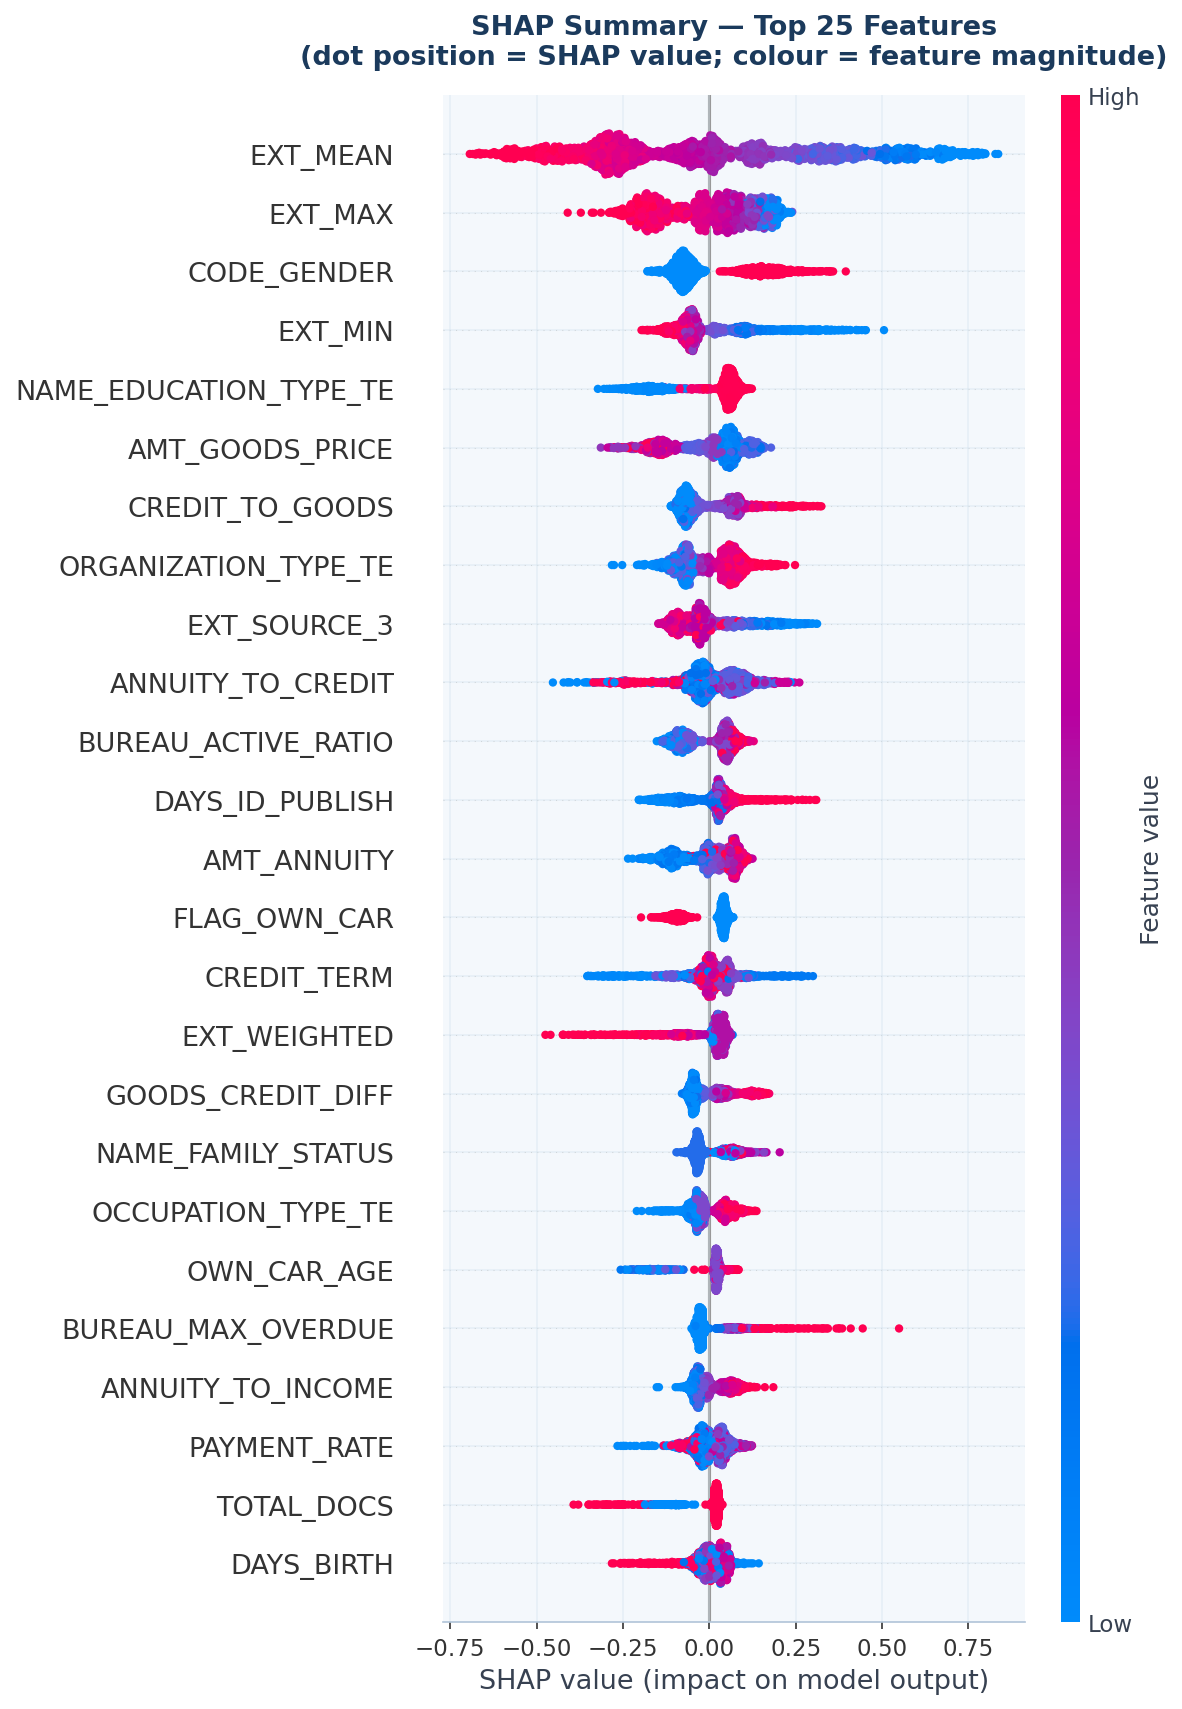

Top 10 SHAP features (mean |SHAP|):
EXT_MEAN                  0.296800
EXT_MAX                   0.113769
CODE_GENDER               0.103782
EXT_MIN                   0.088666
NAME_EDUCATION_TYPE_TE    0.087038
AMT_GOODS_PRICE           0.085214
CREDIT_TO_GOODS           0.073950
ORGANIZATION_TYPE_TE      0.071273
EXT_SOURCE_3              0.071259
ANNUITY_TO_CREDIT         0.069083


In [40]:
fig = plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values.values, X_shap,
    feature_names=FEAT_NAMES,./.l
    max_display=25,
    show=False,
    plot_type='dot',
)
plt.title(
    'SHAP Summary — Top 25 Features\n'
    '(dot position = SHAP value; colour = feature magnitude)',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=FEAT_NAMES
)
print('Top 10 SHAP features (mean |SHAP|):')
print(mean_abs_shap.nlargest(10).to_string())


Low-risk predicted P(default) : 0.0175


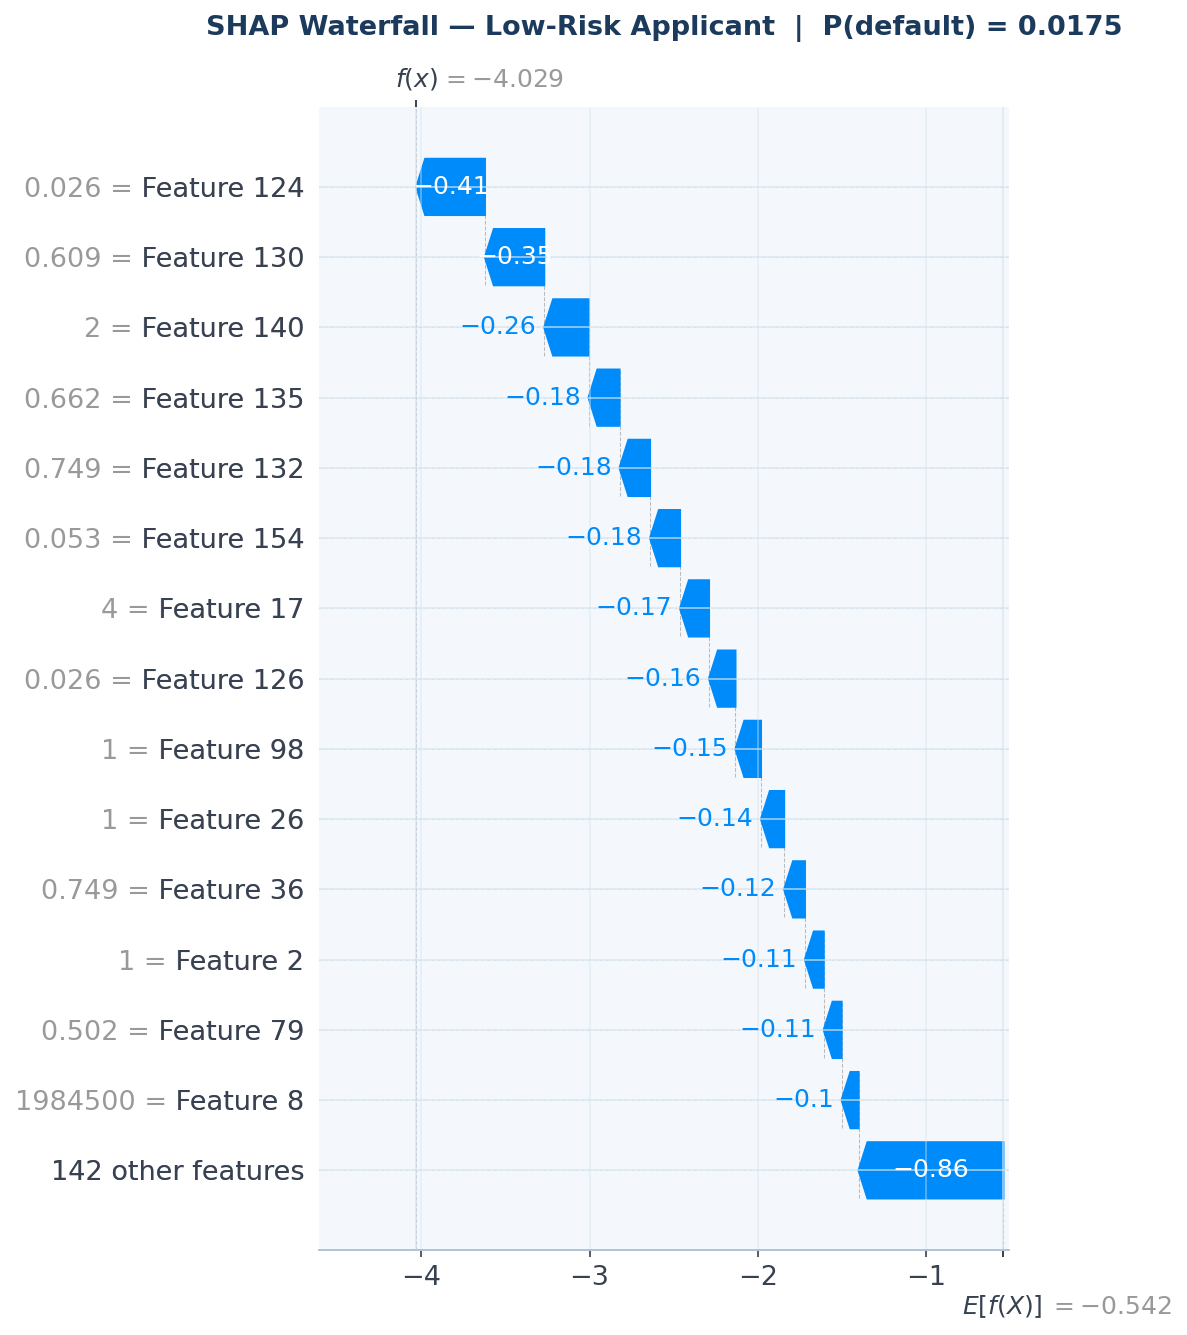

In [41]:
# ── Low-risk applicant ───────────────────────────────────────────────────
low_idx  = np.argmin(y_prob_xgb[sample_idx])
low_prob = y_prob_xgb[sample_idx[low_idx]]
print(f'Low-risk predicted P(default) : {low_prob:.4f}')

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_values[low_idx], max_display=15, show=False)
plt.title(
    f'SHAP Waterfall — Low-Risk Applicant  |  P(default) = {low_prob:.4f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_waterfall_low_risk.png', bbox_inches='tight', dpi=150)
plt.show()


High-risk predicted P(default) : 0.9210


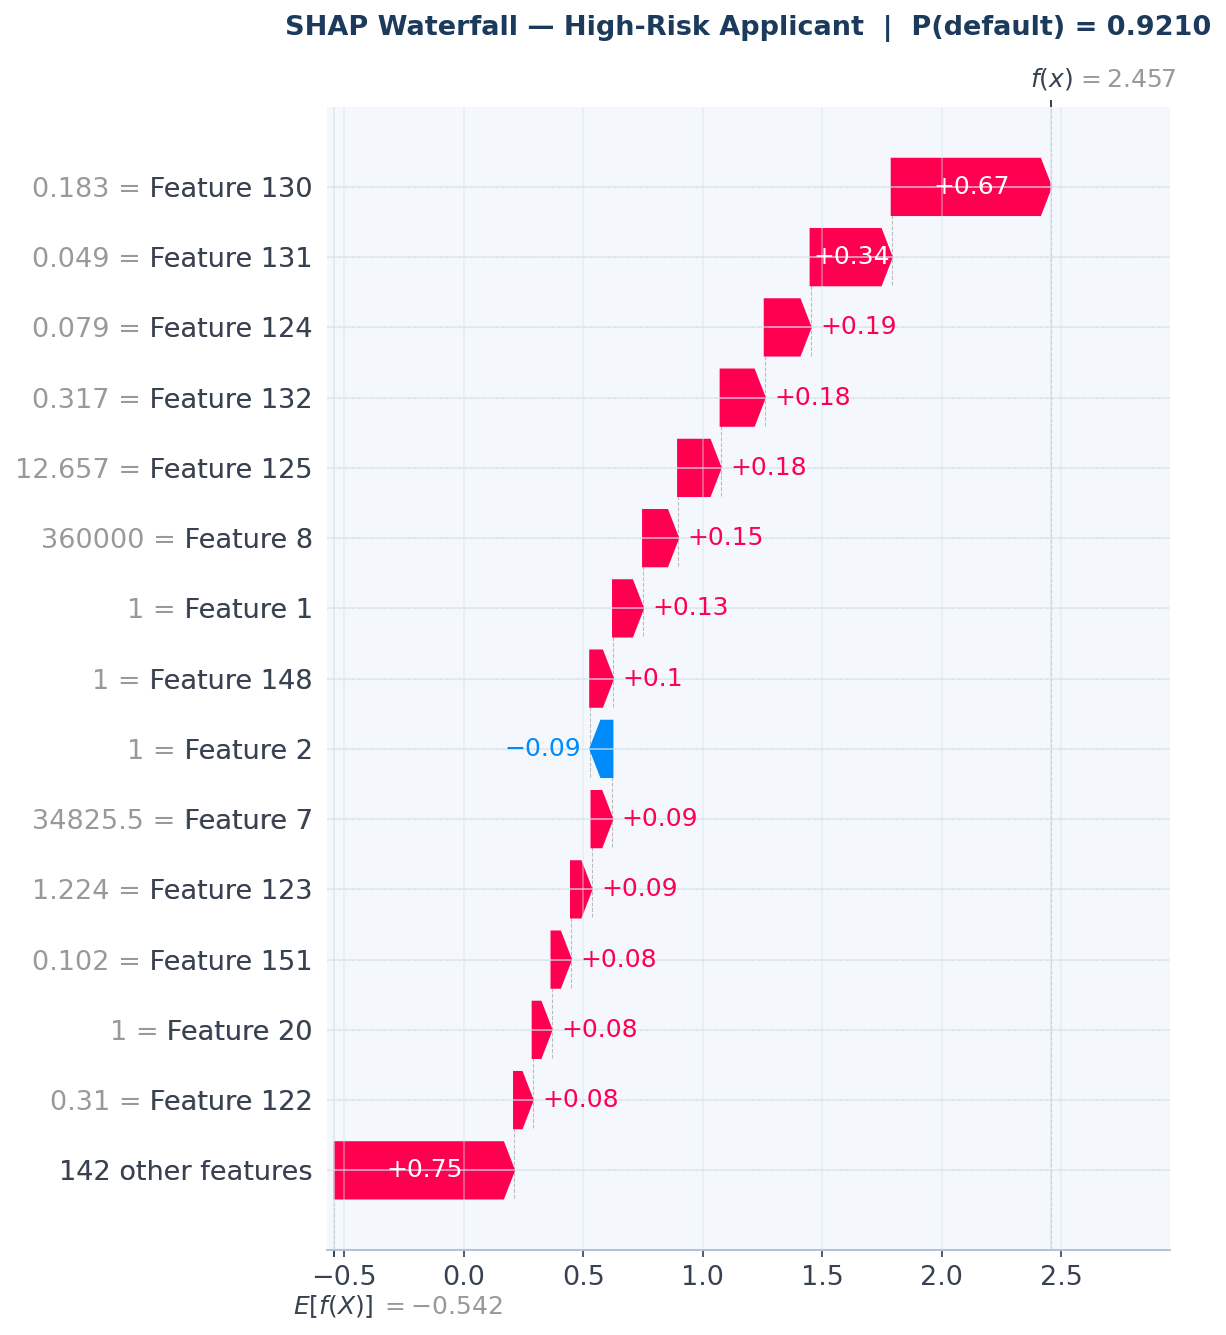

In [42]:
# ── High-risk applicant ──────────────────────────────────────────────────
default_mask  = y_shap == 1
high_idx      = np.where(default_mask)[0][
    np.argmax(y_prob_xgb[sample_idx][default_mask])
]
high_prob = y_prob_xgb[sample_idx[high_idx]]
print(f'High-risk predicted P(default) : {high_prob:.4f}')

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_values[high_idx], max_display=15, show=False)
plt.title(
    f'SHAP Waterfall — High-Risk Applicant  |  P(default) = {high_prob:.4f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_waterfall_high_risk.png', bbox_inches='tight', dpi=150)
plt.show()


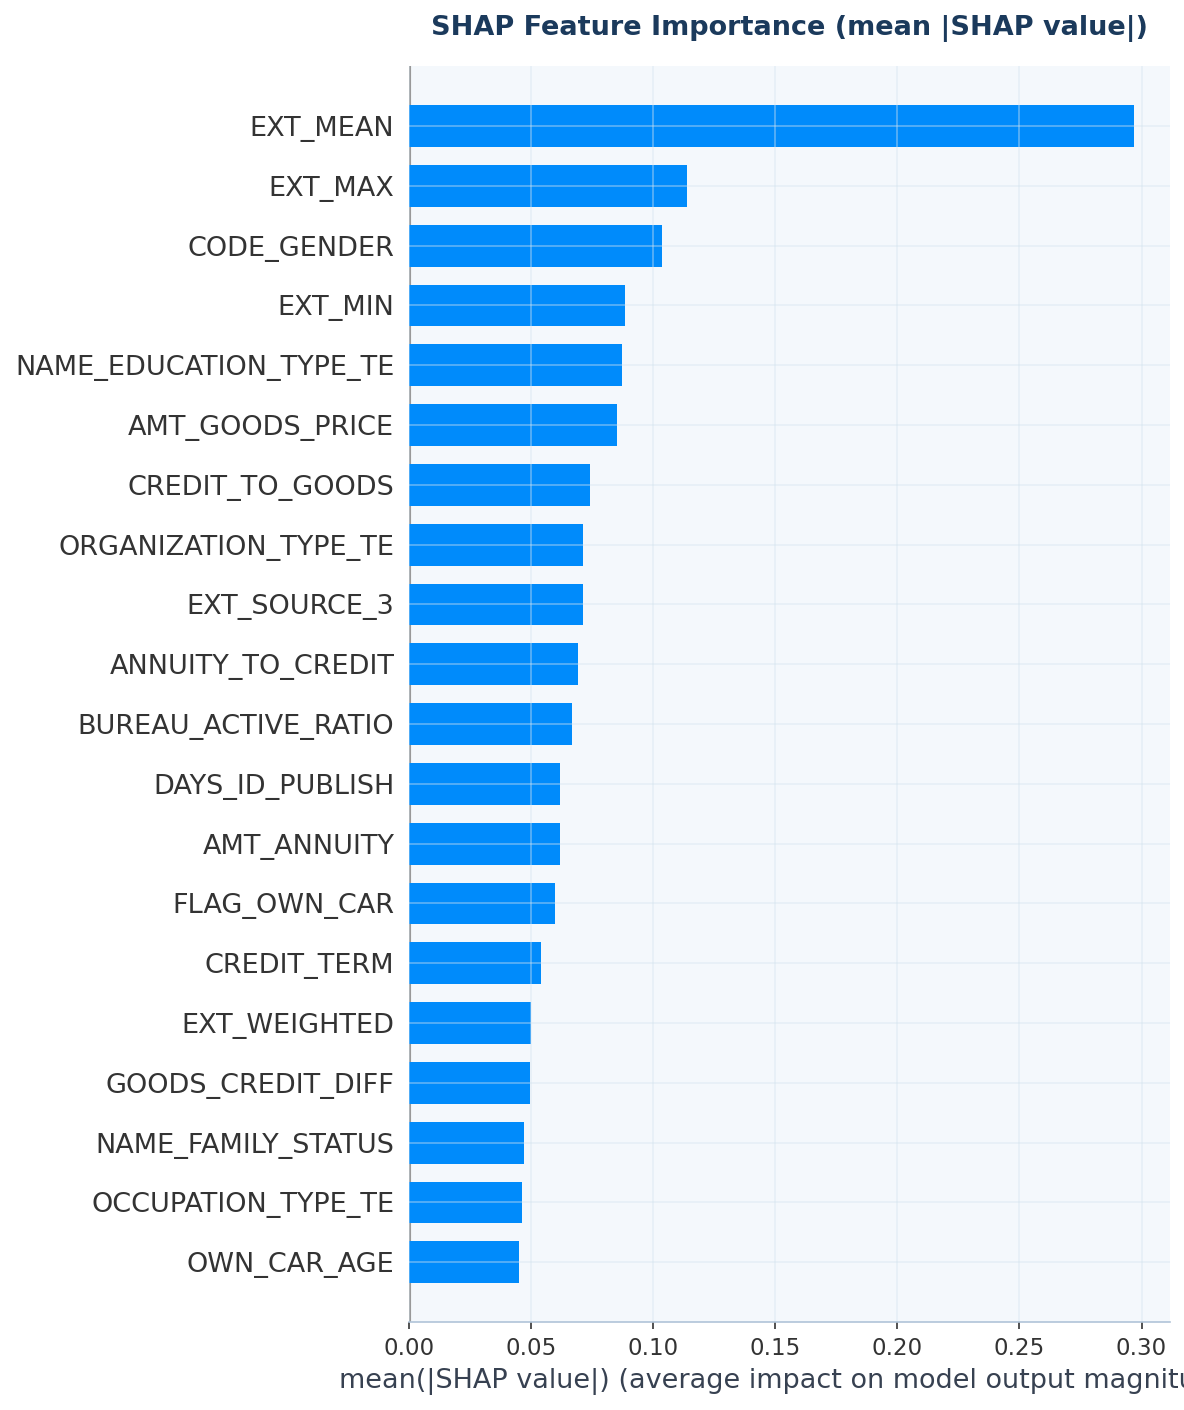

In [43]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values.values, X_shap,
    feature_names=FEAT_NAMES,
    max_display=20,
    plot_type='bar',
    show=False,
)
plt.title('SHAP Feature Importance (mean |SHAP value|)', fontsize=13,
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()


✅ kaggle_submission.csv  shape: (48744, 2)


,SK_ID_CURR,TARGET
0,100001,0.237785
1,100005,0.594414
2,100013,0.110548
3,100028,0.309525
4,100038,0.665352
5,100042,0.292044
6,100057,0.141085
7,100065,0.239424
8,100066,0.125656
9,100067,0.424168


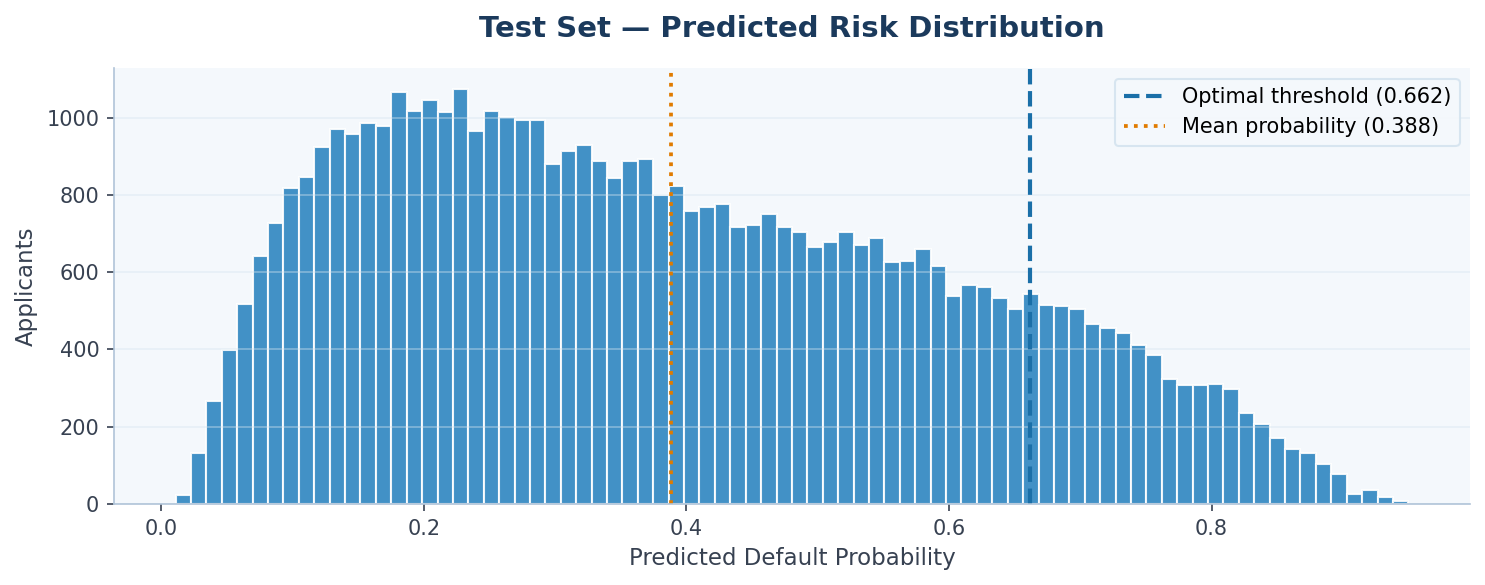

Predicted defaults @ threshold 0.662: 6,682 / 48,744 (13.7%)


In [44]:
test_probs = xgb_model.predict_proba(test_imputed.values)[:, 1]
submission = pd.DataFrame({'SK_ID_CURR': TEST_IDS.values, 'TARGET': test_probs})
submission.to_csv('kaggle_submission.csv', index=False)
print(f'✅ kaggle_submission.csv  shape: {submission.shape}')
display(submission.head(10))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(test_probs, bins=80, color=C_STEEL, edgecolor='white', alpha=0.9)
ax.axvline(xgb_thr, color=C_BLUE_1, linestyle='--', linewidth=2,
           label=f'Optimal threshold ({xgb_thr:.3f})')
ax.axvline(test_probs.mean(), color=C_AMBER, linestyle=':', linewidth=1.8,
           label=f'Mean probability ({test_probs.mean():.3f})')
polish(ax, xlabel='Predicted Default Probability', ylabel='Applicants')
ax.set_title('Test Set — Predicted Risk Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('test_predictions.png', bbox_inches='tight', dpi=150)
plt.show()

n_def = (test_probs >= xgb_thr).sum()
print(f'Predicted defaults @ threshold {xgb_thr:.3f}: '
      f'{n_def:,} / {len(test_probs):,} '
      f'({n_def / len(test_probs) * 100:.1f}%)')


In [45]:
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(scaler,    'scaler.pkl')
joblib.dump(imputer,   'imputer.pkl')
joblib.dump(te_maps,   'te_maps.pkl')
nn.save('nn_model.keras')

with open('feature_columns.json', 'w') as f:
    json.dump(list(train_df.columns), f, indent=2)

with open('cv_results.json', 'w') as f:
    json.dump(
        {k: {'mean': v['mean'], 'std': v['std'], 'fold_aucs': v['fold_aucs']}
         for k, v in cv_results.items()},
        f, indent=2
    )

thresholds = {name: results[name]['Threshold'] for name in results}
with open('thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)

print('✅ Artefacts saved:')
print('   xgb_model.pkl | nn_model.keras | scaler.pkl')
print('   imputer.pkl   | te_maps.pkl')
print('   feature_columns.json | cv_results.json | thresholds.json')


✅ Artefacts saved:
   xgb_model.pkl | nn_model.keras | scaler.pkl
   imputer.pkl   | te_maps.pkl
   feature_columns.json | cv_results.json | thresholds.json


In [46]:
# ── Reload artefacts (simulates cold-start) ───────────────────────────────
_xgb = joblib.load('xgb_model.pkl')
_imp = joblib.load('imputer.pkl')
with open('feature_columns.json') as f:
    _feat_cols = json.load(f)
with open('thresholds.json') as f:
    _thresholds = json.load(f)
_te_maps     = joblib.load('te_maps.pkl')
_global_mean = TARGET.mean()
_xgb_thr     = _thresholds.get('XGBoost', 0.30)


def predict_default_risk(applicant: dict, threshold: float = None) -> dict:
    """
    End-to-end inference for a single applicant.

    Parameters
    ----------
    applicant : dict of raw applicant fields
    threshold : override the default optimal threshold (optional)

    Returns
    -------
    dict with risk_probability, decision, risk_tier, and policy recommendation
    """
    threshold = threshold if threshold is not None else _xgb_thr

    # Step 1 — anomaly fix + feature engineering
    row = pd.DataFrame([applicant])
    if 'DAYS_EMPLOYED' in row.columns:
        row.loc[row['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan
    if 'CODE_GENDER' in row.columns:
        row.loc[row['CODE_GENDER'] == 'XNA', 'CODE_GENDER'] = np.nan
    row = feature_engineering(row)

    # Step 2 — target encoding
    for col, te_map in _te_maps.items():
        if col in row.columns:
            row[col + '_TE'] = row[col].map(te_map).fillna(_global_mean)
            row.drop(columns=[col], inplace=True, errors='ignore')

    # Step 3 — align to training feature set
    full = pd.DataFrame(columns=_feat_cols)
    for c in _feat_cols:
        full[c] = row[c].values if c in row.columns else np.nan
    for col in full.select_dtypes('object').columns:
        full[col] = 0

    # Step 4 — impute → predict
    prob     = float(_xgb.predict_proba(_imp.transform(full[_feat_cols]))[:, 1][0])
    decision = 'DEFAULT' if prob >= threshold else 'NO DEFAULT'

    if   prob < 0.05: tier, policy = 'VERY LOW',  'Premium rates; higher loan limits.'
    elif prob < 0.15: tier, policy = 'LOW',        'Standard approval; normal limits.'
    elif prob < 0.25: tier, policy = 'MODERATE',   'Standard terms; consider collateral.'
    elif prob < 0.40: tier, policy = 'ELEVATED',   'Reduced limit or higher rate; require docs.'
    else:             tier, policy = 'HIGH',        'Decline or require collateral + co-signer.'

    return {
        'risk_probability' : round(prob, 4),
        'risk_percentage'  : f'{prob * 100:.2f}%',
        'decision'         : decision,
        'risk_tier'        : tier,
        'policy'           : policy,
        'threshold_used'   : round(threshold, 4),
    }


print('✅ predict_default_risk() ready.')


✅ predict_default_risk() ready.


In [47]:
examples = [
    ('LOW-RISK', {
        'AMT_INCOME_TOTAL'   : 250_000, 'AMT_CREDIT'     : 400_000,
        'AMT_ANNUITY'        : 18_000,  'AMT_GOODS_PRICE': 380_000,
        'DAYS_BIRTH'         : -16_000, 'DAYS_EMPLOYED'  : -5_000,
        'EXT_SOURCE_1'       : 0.75,    'EXT_SOURCE_2'   : 0.72,
        'EXT_SOURCE_3'       : 0.80,    'CNT_CHILDREN'   : 1,
        'CNT_FAM_MEMBERS'    : 3,
        'OCCUPATION_TYPE'    : 'Accountants',
        'NAME_EDUCATION_TYPE': 'Higher education',
        'REGION_RATING_CLIENT': 1,
    }),
    ('HIGH-RISK', {
        'AMT_INCOME_TOTAL'   : 67_500,  'AMT_CREDIT'     : 450_000,
        'AMT_ANNUITY'        : 28_000,  'AMT_GOODS_PRICE': 430_000,
        'DAYS_BIRTH'         : -9_500,  'DAYS_EMPLOYED'  : -300,
        'EXT_SOURCE_1'       : 0.20,    'EXT_SOURCE_2'   : 0.18,
        'EXT_SOURCE_3'       : 0.22,    'CNT_CHILDREN'   : 2,
        'CNT_FAM_MEMBERS'    : 4,
        'OCCUPATION_TYPE'    : 'Laborers',
        'NAME_EDUCATION_TYPE': 'Secondary / secondary special',
        'REGION_RATING_CLIENT': 3,
    }),
]

for label, applicant in examples:
    r = predict_default_risk(applicant)
    print('=' * 52)
    print(f'  {label}')
    print('=' * 52)
    for k, v in r.items():
        print(f'  {k:<22}: {v}')
    print()


  LOW-RISK
  risk_probability      : 0.0772
  risk_percentage       : 7.72%
  decision              : NO DEFAULT
  risk_tier             : LOW
  policy                : Standard approval; normal limits.
  threshold_used        : 0.662

  HIGH-RISK
  risk_probability      : 0.7707
  risk_percentage       : 77.07%
  decision              : DEFAULT
  risk_tier             : HIGH
  policy                : Decline or require collateral + co-signer.
  threshold_used        : 0.662

